<a href="https://colab.research.google.com/github/alaszmigiel/Obesity-Levels-Prediction/blob/main/Obesity_Levels_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Zbiór danych**

**Nazwa:**
Estimation of Obesity Levels Based on Eating Habits and Physical Condition

**Źródło:**
https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition

**Informacje:**
Zbiór danych dotyczy estymacji poziomu otyłości na podstawie informacji zebranych od osób w wieku od 14 do 61 lat, pochodzących z Meksyku, Peru i Kolumbii. Dane pochodzą z anonimowej ankiety internetowej, w której uczestnicy odpowiadali na pytania związane z ich stylem życia, nawykami żywieniowymi, aktywnością fizyczną oraz parametrami ciała. Po wstępnym etapie zbierania danych przeprowadzono proces zbalansowania zbioru, aby każda klasa poziomu otyłości była reprezentowana w podobnej liczbie przypadków.

**Liczba rekordów:** 2111

**Liczba zmiennych:** 17

**Zmienna docelowa:** NObeyesdad – poziom otyłości

###**Opis zmiennych:**

**Dane demograficzne i fizyczne:** <br> •	Gender – Płeć (female/male) <br> •	Age – Wiek (w latach) <br> •	Height – Wzrost (w metrach) <br> •	Weight – Waga (w kilogramach) <br> •	family_history_with_overweight – Członek rodziny zmaga/zmagał się z nadwagą (yes/no)

**Nawyki żywieniowe:** <br>
•	FAVC – Częste spożywanie wysokokalorycznego jedzenia (yes/no) <br> •	FCVC – Częstość spożywania warzyw <br> •	NCP – Liczba głównych posiłków dziennie <br> •	CAEC – Częstość spożywania przekąsek między posiłkami (always/frequently/sometimes/no) <br> •	SMOKE – Palenie (yes/no) <br> •	CH2O – Dzienne spożycie wody (w litrach) <br> •	CALC – Częstość spożycia alkoholu (always/frequently/sometimes/no)

**Styl życia i aktywność fizyczna:**
•	SCC – Monitorowanie spożycia kalorii (yes/no) <br> •	FAF – Częstość aktywności fizycznej <br> •	TUE – Czas spędzany na urządzeniach elektronicznych (w godzinach) <br> •	MTRANS – Główny środek transportu (automobile/bike/motorbike/walking/public transportation)

**Zmienna docelowa:**
NObeyesdad <br> •	Insufficient_Weight (niedowaga) <br> •	Normal_Weight (waga prawidłowa) <br> •	Overweight_Level_I (nadwaga I stopnia) <br> •	Overweight_Level_II (nadwaga II stopnia) <br> •	Obesity_Type_I (otyłość I stopnia) <br> •	Obesity_Type_II (otyłość II stopnia) <br> •	Obesity_Type_III (otyłość III stopnia)

###**Metodologia zbierania danych:**
Dane zostały zebrane za pomocą internetowej ankiety, po zebraniu danych przeprowadzono proces zbalansowania klas, żeby zapewnić równomierną reprezentację poziomów otyłości.
<br> •	23% danych pochodzi z odpowiedzi użytkowników
<br> •	77% danych zostało syntetycznie wygenerowanych przy pomocy narzędzia Weka i SMOTE

## **Import danych**

Instalacja potrzebnych pakietów



In [ ]:
install.packages("dplyr")
install.packages("ggplot2")
install.packages("tidyr")
install.packages("corrplot")
install.packages("caret")
install.packages("pROC")
install.packages("rpart.plot")
install.packages("randomForest")
install.packages("RSNNS")
install.packages("NeuralNetTools")
install.packages("nnet")
install.packages("xgboost")
install.packages("MLmetrics")
install.packages("kernlab")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Ins

Ładowanie pakietów

In [ ]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(caret)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: lattice



Wczytanie danych z linku do pliku CSV i przygotowanie do dalszej analizy poprzez zmianę typu zmiennych kategorycznych (Gender, CALC, FAVC, SCC, SMOKE, family_history_with_overweight, CAEC, MTRANS, NObeyesdad) na faktory

In [ ]:
url <- "https://drive.google.com/uc?export=download&id=1_KFx_q34cyyPaoGSMQWRI43gakARc1e4"

dataset <- read.csv(url, sep = ",")

cols_to_factor <- c("Gender", "CALC", "FAVC", "SCC", "SMOKE",
                    "family_history_with_overweight", "CAEC", "MTRANS", "NObeyesdad")
dataset[cols_to_factor] <- lapply(dataset[cols_to_factor], factor)

str(dataset)

'data.frame':	2111 obs. of  17 variables:
 $ Age                           : num  21 21 23 27 22 29 23 22 24 22 ...
 $ Gender                        : Factor w/ 2 levels "Female","Male": 1 1 2 2 2 2 1 2 2 2 ...
 $ Height                        : num  1.62 1.52 1.8 1.8 1.78 1.62 1.5 1.64 1.78 1.72 ...
 $ Weight                        : num  64 56 77 87 89.8 53 55 53 64 68 ...
 $ CALC                          : Factor w/ 4 levels "Always","Frequently",..: 3 4 2 2 4 4 4 4 2 3 ...
 $ FAVC                          : Factor w/ 2 levels "no","yes": 1 1 1 1 1 2 2 1 2 2 ...
 $ FCVC                          : num  2 3 2 3 2 2 3 2 3 2 ...
 $ NCP                           : num  3 3 3 3 1 3 3 3 3 3 ...
 $ SCC                           : Factor w/ 2 levels "no","yes": 1 2 1 1 1 1 1 1 1 1 ...
 $ SMOKE                         : Factor w/ 2 levels "no","yes": 1 2 1 1 1 1 1 1 1 1 ...
 $ CH2O                          : num  2 3 2 2 2 2 2 2 2 2 ...
 $ family_history_with_overweight: Factor w/ 2 levels "n

## **Wstępna analiza danych**

Sprawdzenie typów zmiennych i przykładowych wartości


In [ ]:
glimpse(dataset)

Rows: 2,111
Columns: 17
$ Age                            <dbl> 21, 21, 23, 27, 22, 29, 23, 22, 24, 22,…
$ Gender                         <fct> Female, Female, Male, Male, Male, Male,…
$ Height                         <dbl> 1.62, 1.52, 1.80, 1.80, 1.78, 1.62, 1.5…
$ Weight                         <dbl> 64.0, 56.0, 77.0, 87.0, 89.8, 53.0, 55.…
$ CALC                           <fct> no, Sometimes, Frequently, Frequently, …
$ FAVC                           <fct> no, no, no, no, no, yes, yes, no, yes, …
$ FCVC                           <dbl> 2, 3, 2, 3, 2, 2, 3, 2, 3, 2, 3, 2, 3, …
$ NCP                            <dbl> 3, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3, 3, 3, …
$ SCC                            <fct> no, yes, no, no, no, no, no, no, no, no…
$ SMOKE                          <fct> no, yes, no, no, no, no, no, no, no, no…
$ CH2O                           <dbl> 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 3, …
$ family_history_with_overweight <fct> yes, yes, yes, no, no, no, yes, no, yes…
$ FAF           

Podsumowanie statystyk opisowych dla zmiennych liczbowych oraz rozkładów zmiennych kategorycznych  

In [ ]:
summary(dataset)

      Age           Gender         Height          Weight      
 Min.   :14.00   Female:1043   Min.   :1.450   Min.   : 39.00  
 1st Qu.:19.95   Male  :1068   1st Qu.:1.630   1st Qu.: 65.47  
 Median :22.78                 Median :1.700   Median : 83.00  
 Mean   :24.31                 Mean   :1.702   Mean   : 86.59  
 3rd Qu.:26.00                 3rd Qu.:1.768   3rd Qu.:107.43  
 Max.   :61.00                 Max.   :1.980   Max.   :173.00  
                                                               
         CALC       FAVC           FCVC            NCP         SCC      
 Always    :   1   no : 245   Min.   :1.000   Min.   :1.000   no :2015  
 Frequently:  70   yes:1866   1st Qu.:2.000   1st Qu.:2.659   yes:  96  
 no        : 639              Median :2.386   Median :3.000             
 Sometimes :1401              Mean   :2.419   Mean   :2.686             
                              3rd Qu.:3.000   3rd Qu.:3.000             
                              Max.   :3.000   Max.

Liczba wierszy i kolumn w zbiorze

In [ ]:
dim(dataset)

[1] 2111   17

## **Analiza różnorodności i braków w danych**

Ilość unikalnych wartości każdej zmiennej, sprawdzenie, czy każda ma co najmniej dwie

In [ ]:
dataset %>%
  summarise(across(everything(), ~ n_distinct(.))) %>%
  pivot_longer(cols = everything(), names_to = "variable", values_to = "unique") %>%
  arrange(unique)

variable,unique
<chr>,<int>
Gender,2
FAVC,2
SCC,2
SMOKE,2
family_history_with_overweight,2
CALC,4
CAEC,4
MTRANS,5
NObeyesdad,7


Sprawdzenie braków w danych

In [ ]:
dataset %>%
  summarise(across(everything(), ~ sum(is.na(.)))) %>%
  pivot_longer(cols = everything(), names_to = "variable", values_to = "missing") %>%
  filter(missing == 0)

variable,missing
<chr>,<int>
Age,0
Gender,0
Height,0
Weight,0
CALC,0
FAVC,0
FCVC,0
NCP,0
SCC,0


## **Wizualizacja danych**

#### **Rozkład zmiennej docelowej**


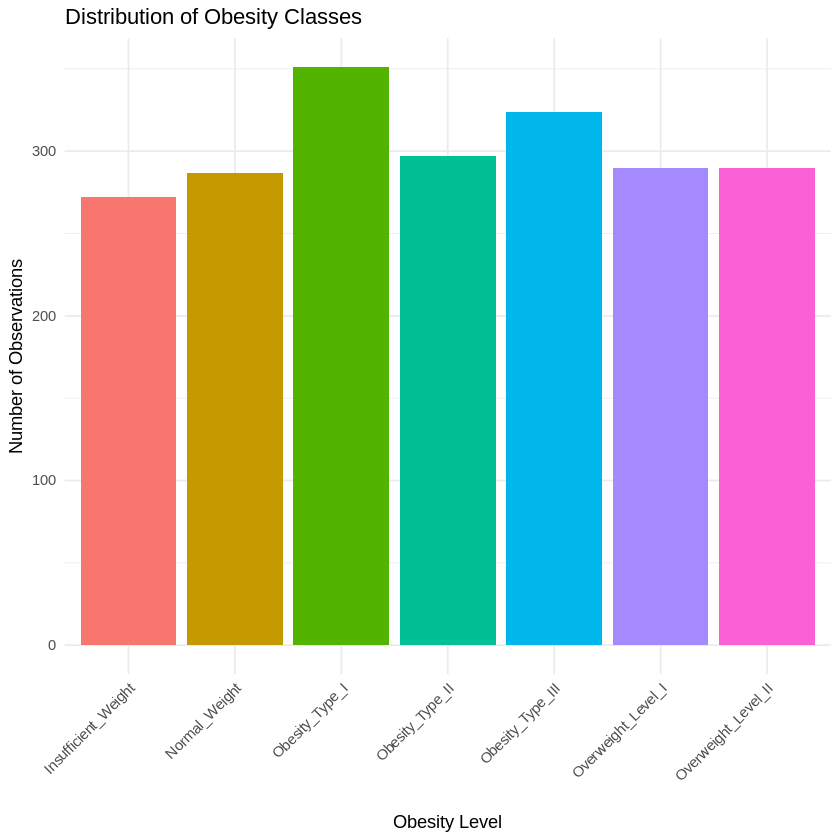

In [ ]:
ggplot(dataset, aes(x = NObeyesdad, fill = NObeyesdad)) +
  geom_bar() +
  theme_minimal() +
  labs(title = "Distribution of Obesity Classes", x = "Obesity Level", y = "Number of Observations") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  guides(fill = "none")

Wykres przedstawia ilość przypadków należących do każdej z klas zmiennej docelowej NObeyesdad, która opisuje poziom otyłości. Na wykresie widać, że liczebność klas jest zrównoważona — każda z siedmiu kategorii zawiera od około 270 do 350 obserwacji. Oznacza to, że zbiór danych został wcześniej zbalansowany (co potwierdza opis zbioru) i nie występuje problem klasy dominującej.

### **Zmienne względem klasy otyłości i płci**

**Rozkład wzrostu względem poziomu otyłości**


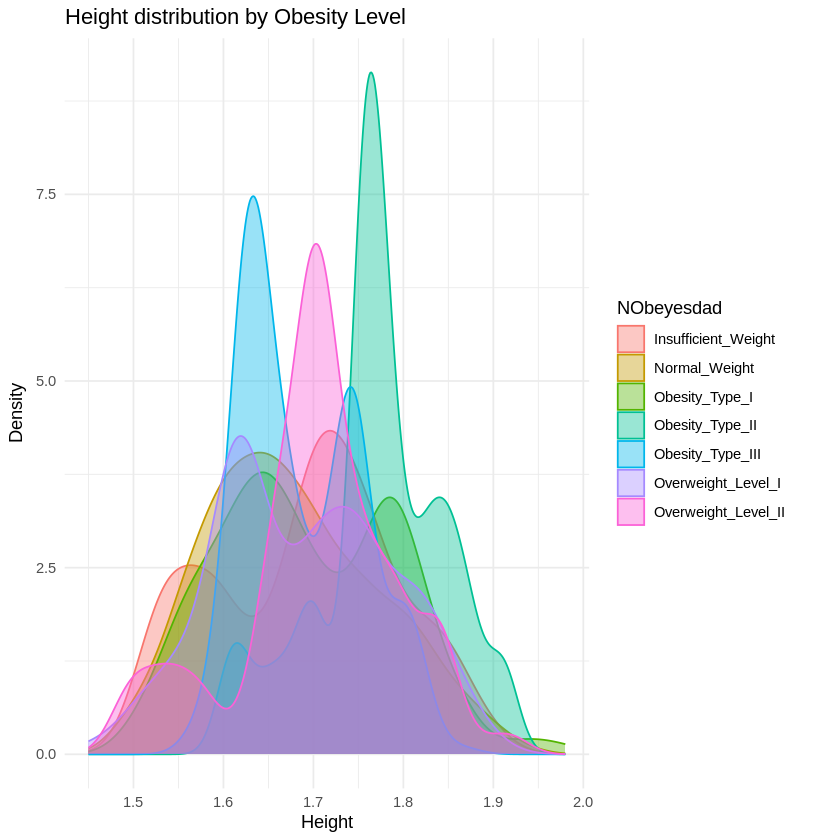

In [ ]:
ggplot(dataset, aes(x = Height, fill = NObeyesdad, color = NObeyesdad)) +
  geom_density(alpha = 0.4) +
  theme_minimal() +
  labs(title = "Height distribution by Obesity Level", x = "Height", y = "Density")

Wykres gęstości przedstawia rozkład wzrostu w podziale na poszczególne klasy zmiennej docelowej. Nie widać wyraźnej zależności między wzrostem a poziomem otyłości, rozkłady różnych klas w dużym stopniu się pokrywają. Największą uwagę zwraca przewaga niższego wzrostu wśród osób z kategorią Obesity_Type_III oraz duża ilość osób powyżej 1.75m znajdujących się w kategorii Obesity_Type_II. Osoby ze skrajną otyłością mają najczęściej 1.7m. Widać również, że osoby o prawidłowej wadze (Normal_Weight) lub Insufficient_Weight są częściej w zakresie około 1.6–1.7 metra.

**Rozkład wieku względem poziomu otyłości**



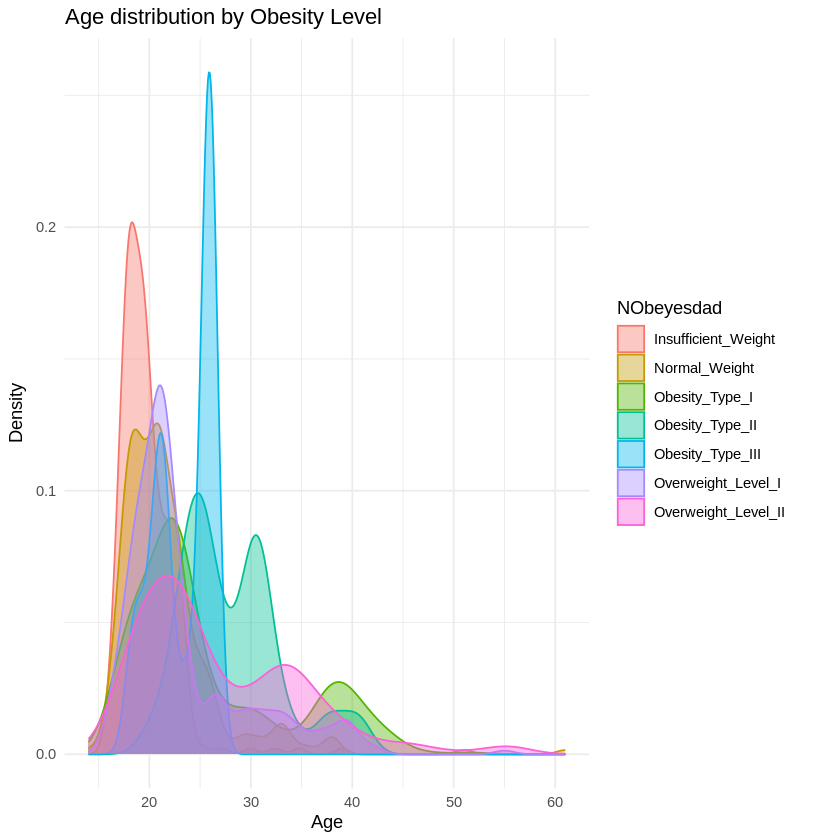

In [ ]:
ggplot(dataset, aes(x = Age, fill = NObeyesdad, color = NObeyesdad)) +
  geom_density(alpha = 0.4) +
  theme_minimal() +
  labs(title = "Age distribution by Obesity Level", x = "Age", y = "Density")

Wykres gęstości przedstawia rozkład wieku badanych osób w podziale na klasy poziomu otyłości. Widać, że największe skupienie przypadków dla większości klas otyłości znajduje się w przedziale wiekowym od ok. 20 do 30 lat. Klasa Obesity_Type_III jest wyraźnie większa w okolicy 26–27 lat, natomiast Insufficient_Weight i Normal_Weight występują częściej u młodszych osób, zwłaszcza w przedziale 18–22 lata. Dane są silnie skoncentrowane na młodych dorosłych, co może wynikać z metodologii zbierania danych (internetowa ankieta).

**Wiek względem wagi według płci**



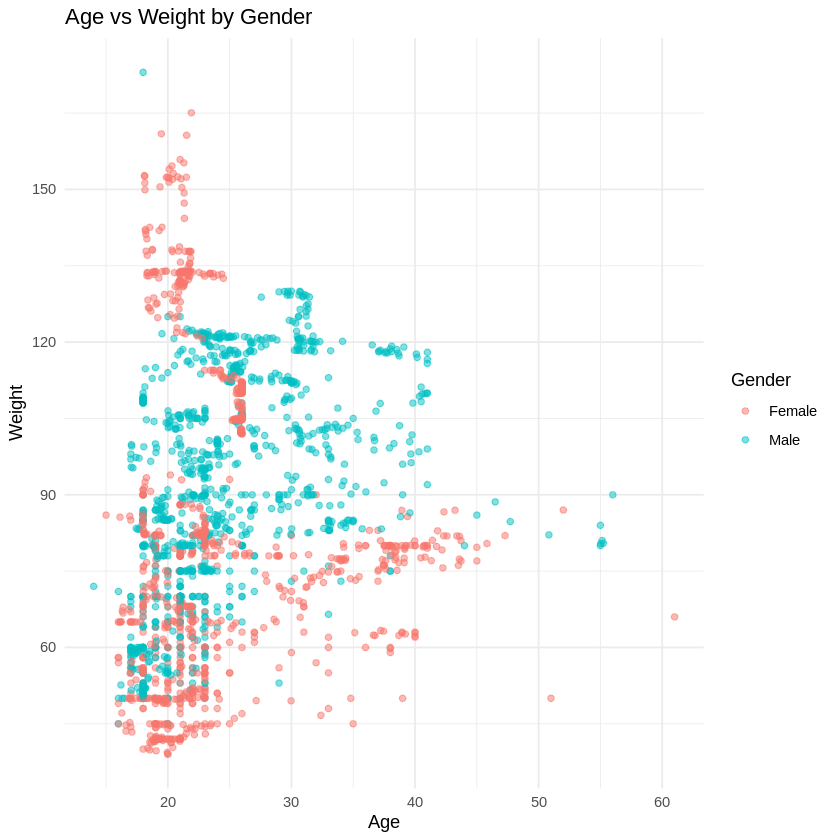

In [ ]:
ggplot(dataset, aes(x = Age, y = Weight, color = Gender)) +
  geom_point(alpha = 0.5) +
  theme_minimal() +
  labs(title = "Age vs Weight by Gender")

Wykres punktowy przedstawia zależność pomiędzy wiekiem a wagą respondentów, rozróżniając płeć. Każdy punkt odpowiada jednej osobie w zbiorze danych. Wykres pokazuje, że większość danych skupia się w przedziale wiekowym od 18 do 30 lat oraz w zakresie wagi od około 50 do 120 kg. Mężczyźni częściej ważą więcej niż 90kg, ale mniej niż 120kg, a kobiety ważą najczęściej do 90kg, lub powyżej 120kg. Widać też duże skupisko kobiet ważących 110-115kg mających ok. 26 lat. Wnioskując z wykresu, nie ma wyraźnego trendu wzrostu wagi z wiekiem, jednak płeć może wpływać na rozkład wagowy w danym przedziale wiekowym.

**Wiek względem wzrostu według płci**



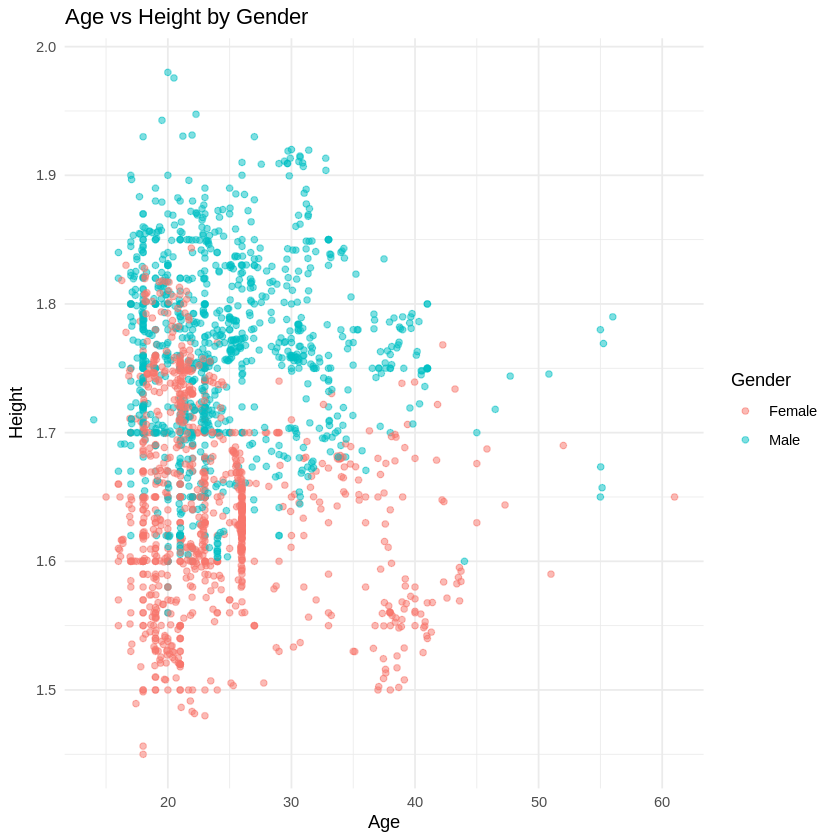

In [ ]:
ggplot(dataset, aes(x = Age, y = Height, color = Gender)) +
  geom_point(alpha = 0.5) +
  theme_minimal() +
  labs(title = "Age vs Height by Gender")

Wykres przedstawia zależność między wiekiem a wzrostem badanych osób z uwzględnieniem płci. Każdy punkt na wykresie odpowiada jednej osobie. Na wykresie widać, że wzrost nie wykazuje dużych zmian w zależności od wieku – pozostaje mniej więcej stabilny w całym przedziale wiekowym (14–61 lat), co jest zgodne z oczekiwaniami. Mężczyźni w większości przypadków są wyżsi niż kobiety. Dane są najbardziej skoncentrowane w zakresie od około 1.55 m do 1.85 m.

**Waga a wzrost według poziomu otyłości**



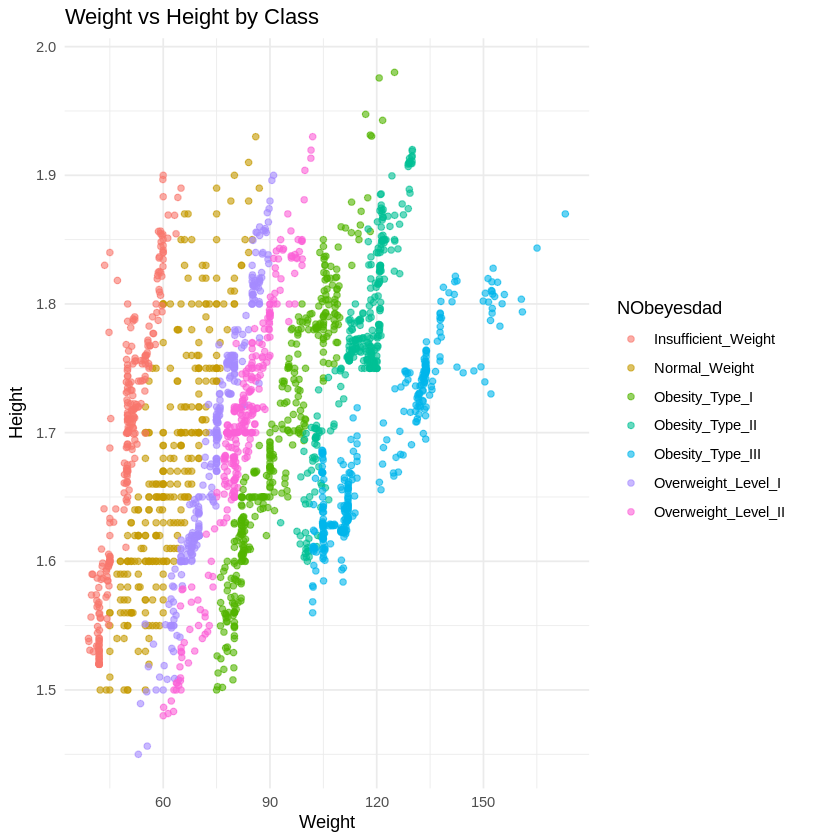

In [ ]:
ggplot(dataset, aes(x = Weight, y = Height, color = NObeyesdad)) +
  geom_point(alpha = 0.6) +
  labs(title = "Weight vs Height by Class", x = "Weight", y = "Height", color = "Class") +
  theme_minimal() +
  scale_color_discrete(name = "NObeyesdad")

Wykres przedstawia zależność między wagą a wzrostem osób, z podziałem na klasy poziomu otyłości. Każdy punkt reprezentuje jedną osobę. Wykres pokazuje wyraźny podział klas otyłości w zależności od masy ciała, co potwierdza, że waga ma istotny wpływ na przypisanie do konkretnej klasy. Mimo to, niektóre kategorie częściowo się pokrywają. Wzrost pełni rolę pomocniczą, dla tej samej wagi osoby niższe częściej są przypisane do wyższych klas otyłości.

### **Wykresy kołowe dla zmiennych kategorycznych**

Wykresy kołowe przedstawiają procentowy rozkład odpowiedzi dla wybranych zmiennych kategorycznych w zbiorze danych.



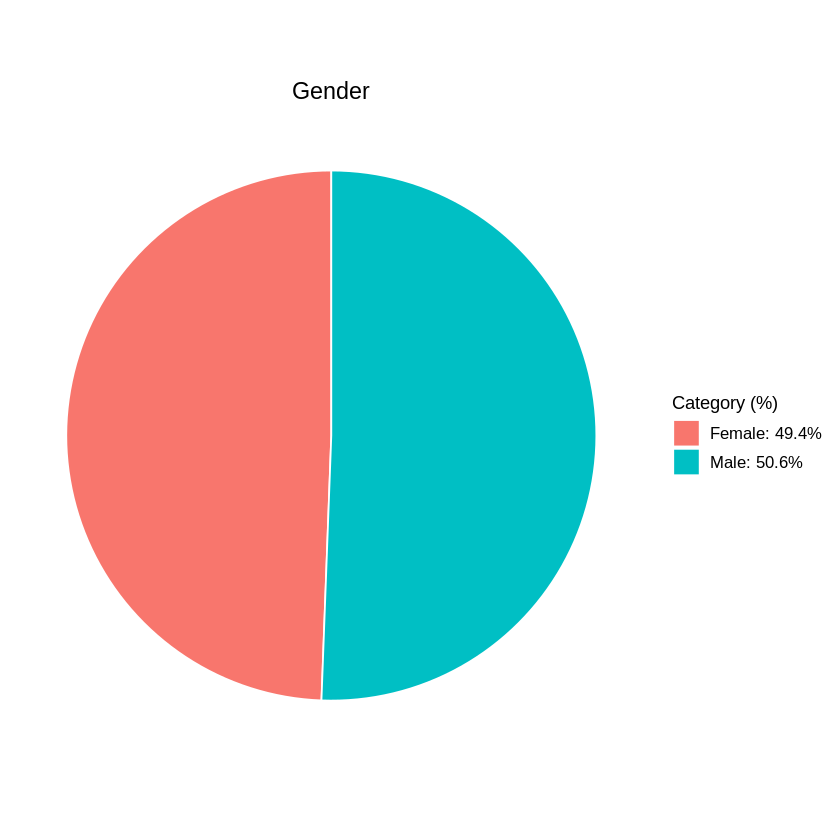

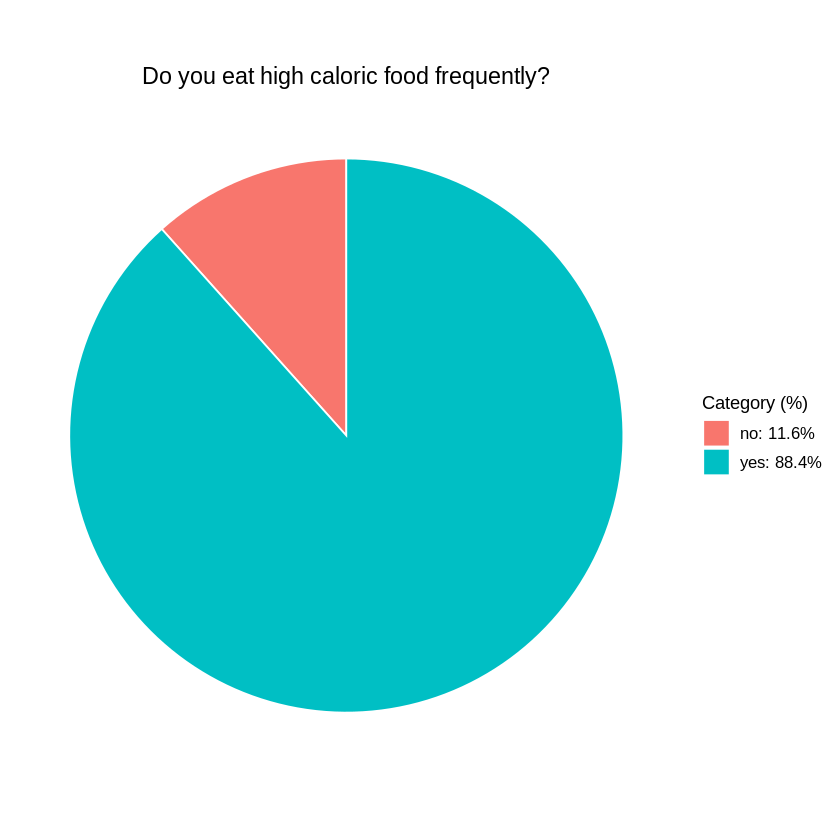

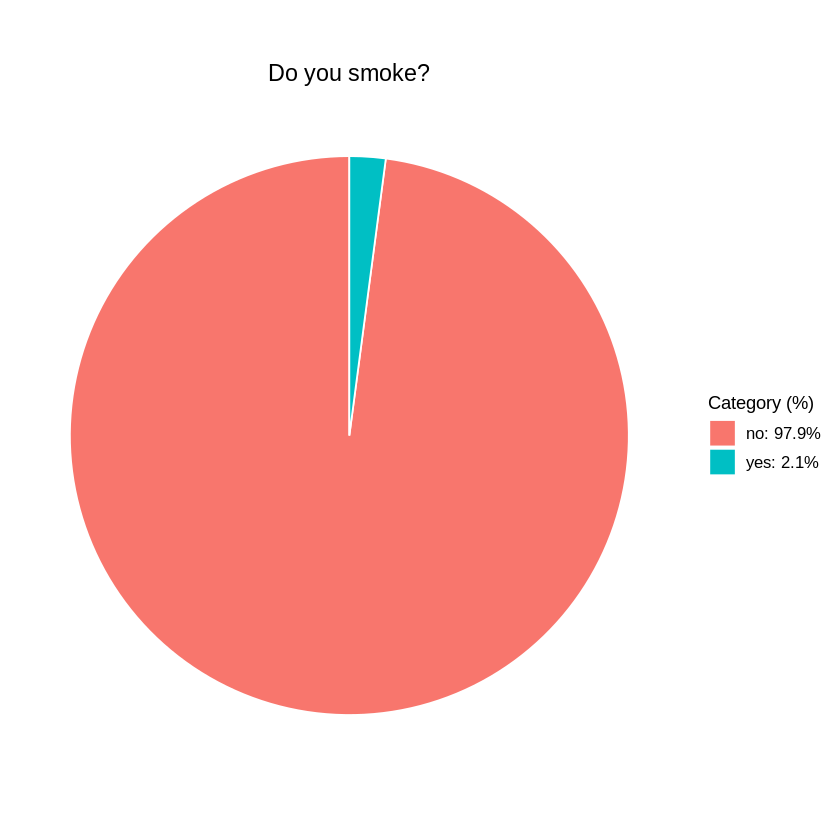

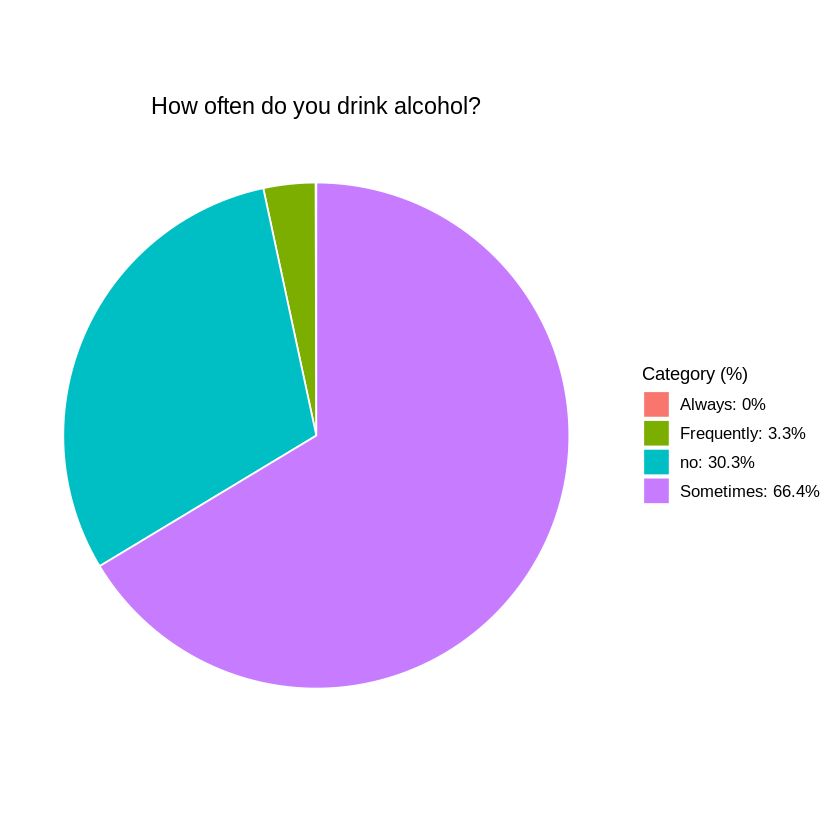

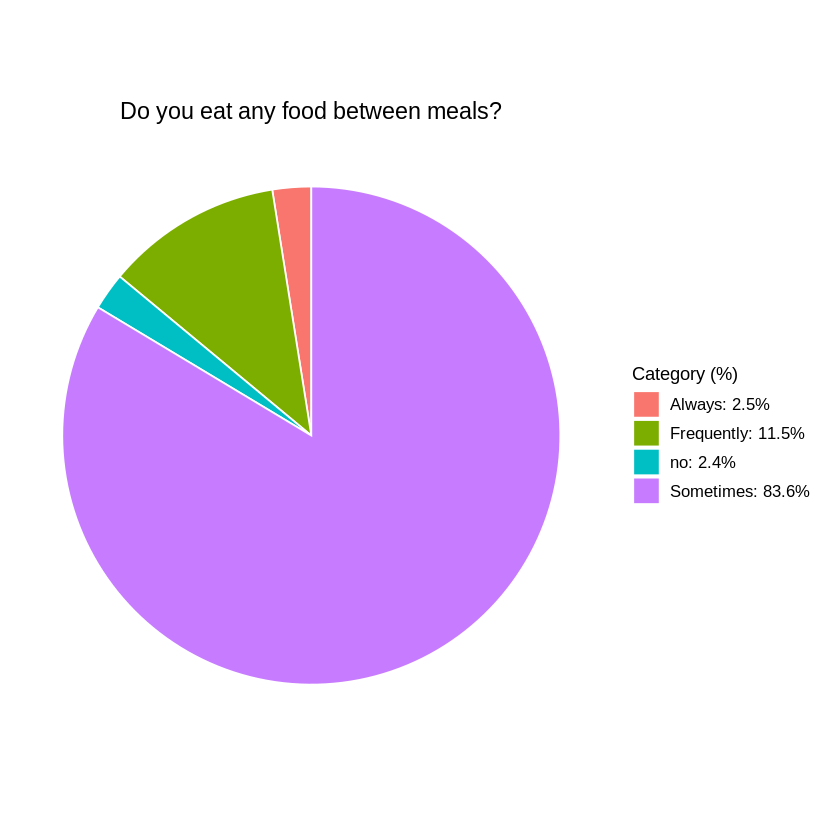

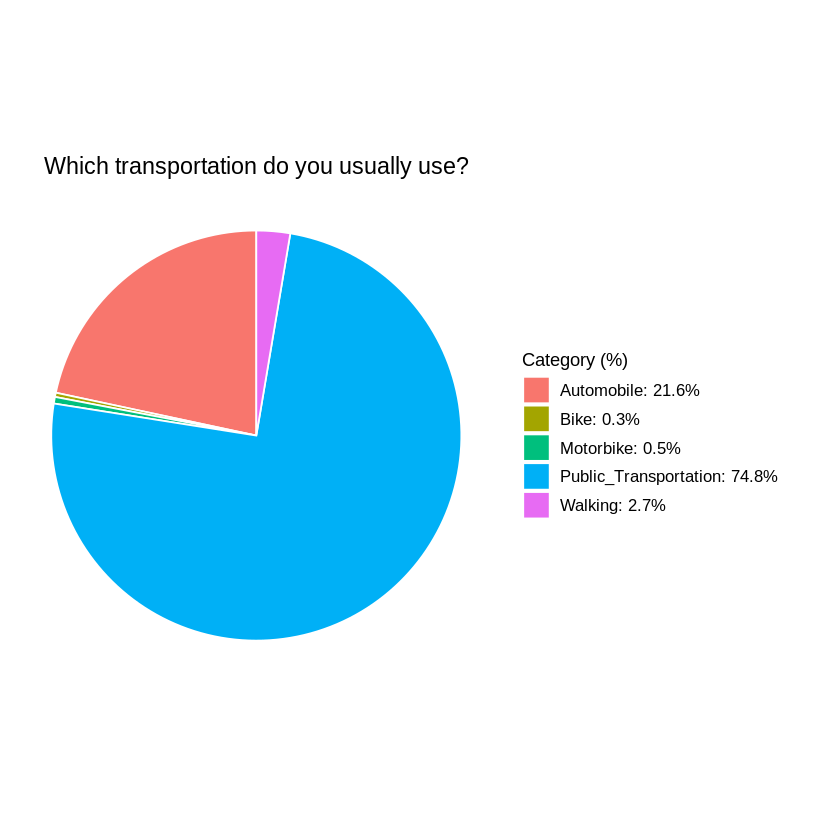

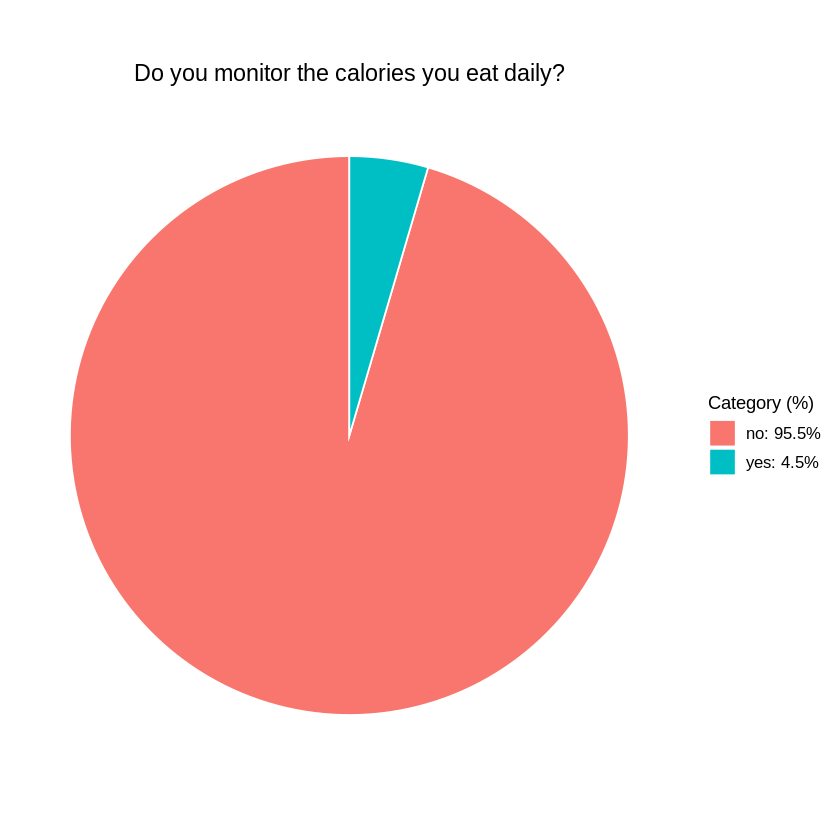

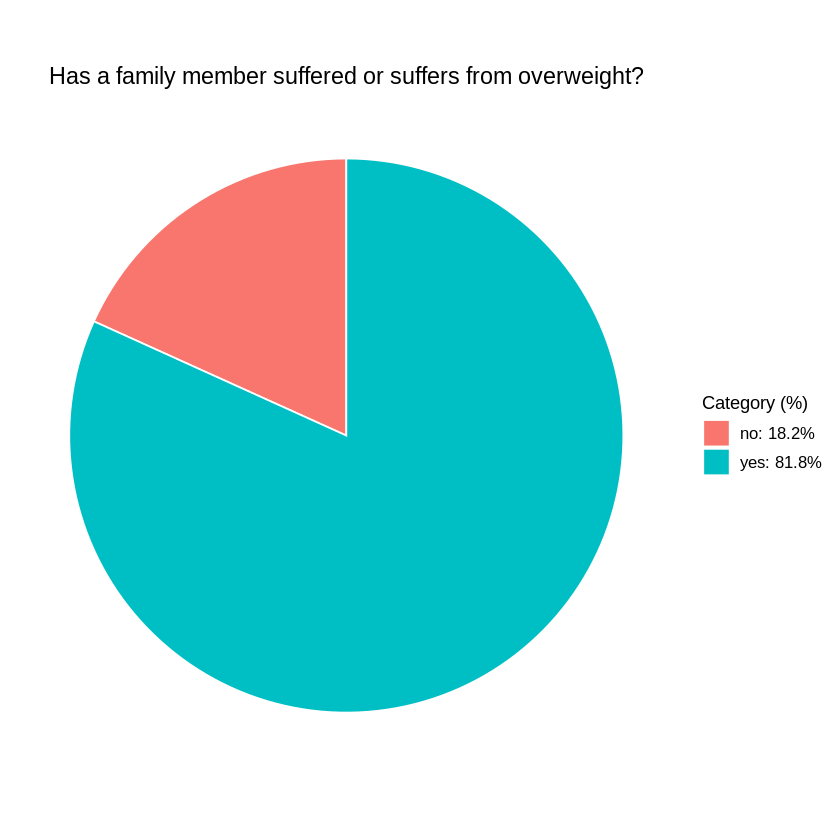

In [ ]:
pie_chart <- function(df, kolumna, tytul) {
  pie_data <- df %>%
    count(.data[[kolumna]]) %>%
    mutate(
      pct = round(100 * n / sum(n), 1),
      label = paste0(.data[[kolumna]], ": ", pct, "%")
    )

  ggplot(pie_data, aes(x = "", y = n, fill = label)) +
    geom_bar(stat = "identity", width = 1, color = "white") +
    coord_polar(theta = "y") +
    labs(
      title = tytul,
      x = NULL, y = NULL, fill = "Category (%)"
    ) +
    theme_void() +
    theme(
      plot.title = element_text(hjust = 0.5, size = 14),
      legend.title = element_text(size = 11),
      legend.text = element_text(size = 10),
      legend.position = "right"
    )
}

pie_chart(dataset, "Gender", "Gender")
pie_chart(dataset, "FAVC", "Do you eat high caloric food frequently?")
pie_chart(dataset, "SMOKE", "Do you smoke?")
pie_chart(dataset, "CALC", "How often do you drink alcohol?")
pie_chart(dataset, "CAEC", "Do you eat any food between meals?")
pie_chart(dataset, "MTRANS", "Which transportation do you usually use?")
pie_chart(dataset, "SCC", "Do you monitor the calories you eat daily?")
pie_chart(dataset, "family_history_with_overweight", "Has a family member suffered or suffers from overweight?")

•	**Gender** - płeć rozkłada się praktycznie równo – mężczyźni stanowią niewielką większość.
<br> •	**FAVC** (Częste spożywanie wysokokalorycznego jedzenia) - aż 88% badanych odpowiedziało, że często spożywa wysokokaloryczne jedzenie.
<br> •	**SMOKE** (Czy palisz?) - ponad 97% badanych odpowiedziało, że nie pali.
<br> •	**CALC** (Częstość spożycia alkoholu) - najwięcej osób spożywa alkohol „czasami” (66%), natomiast tylko 3% odpowiedziało, że pije często. Nikt z ankietowanych nie odpowiedział, że pije zawsze.
<br> •	**CAEC** (Podjadanie między posiłkami) - 97,6% osób odpowiedziało, że podjada między posiłkami, z czego większość „czasami”.
<br> •	**MTRANS** (Środek transportu) – zdecydowanie najpopularniejszym środkiem transportu jest transport publiczny (74.8%), ankietowani rzadziej używają samochodów lub rowerów.
<br> •	**SCC** (Czy kontrolujesz spożycie kalorii?) - tylko 4.5% osób monitoruje codzienne spożycie kalorii.
<br> •	**Family history with overweight** (Historia nadwagi w rodzinie) - większość (81.8%) osób ma w rodzinie przypadki nadwagi.

### **Histogramy zmiennych liczbowych**


Histogramy pokazują rozkłady wartości sześciu zmiennych liczbowych w zbiorze danych.


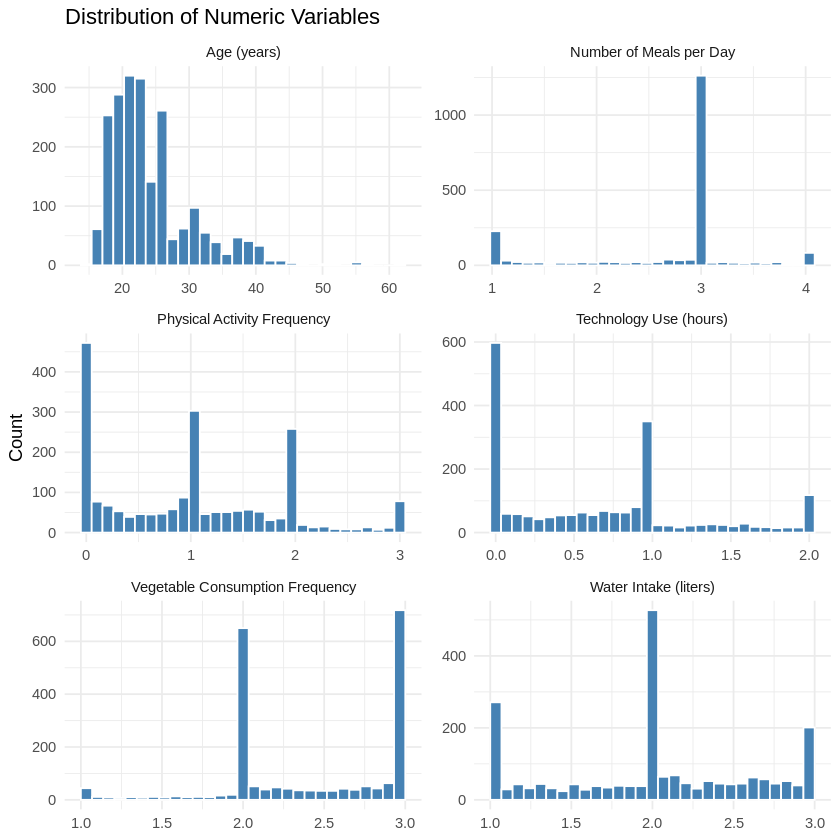

In [ ]:
numeric_vars <- dataset %>%
  select(Age, FCVC, NCP, CH2O, FAF, TUE)
long_data <- pivot_longer(numeric_vars, cols = everything(), names_to = "Variable", values_to = "Value")

new_labels <- tibble(
  Variable = c("Age", "FCVC", "NCP", "CH2O", "FAF", "TUE"),
  Label = c(
    "Age (years)",
    "Vegetable Consumption Frequency",
    "Number of Meals per Day",
    "Water Intake (liters)",
    "Physical Activity Frequency",
    "Technology Use (hours)"
  )
)
long_data <- left_join(long_data, new_labels, by = "Variable")

ggplot(long_data, aes(x = Value)) +
  geom_histogram(fill = "steelblue", color = "white", bins = 30) +
  facet_wrap(~Label, scales = "free", ncol = 2) +
  theme_minimal() +
  labs(
    title = "Distribution of Numeric Variables",
    x = NULL, y = "Count"
  )

•	**Age** - najwięcej osób ma od 18 do 25 lat.
<br> •	**NCP** (Liczba posiłków dziennie) - prawie wszyscy badani odpowiedzieli, że spożywają 3 posiłki dziennie.
<br> •	**FAF** (Aktywność fizyczna) - rozkład jest zróżnicowany – są osoby nieaktywne oraz takie ćwiczące więcej. Tu znów mało kto wpisał w ankiecie niecałkowitą liczbę godzin.
<br> •	**TUE** (Czas korzystania z technologii) - najwięcej osób spędza niewiele czasu przed urządzeniami (0–1 godzina dziennie), ale są też grupy z 2–3 godzinami. Tu również mało kto wpisał w ankiecie niecałkowitą liczbę.
<br> •	**FCVC** (Częstość spożycia warzyw) - większość osób spożywa warzywa regularnie.
<br> •	**CH2O** (Spożycie wody w litrach) - występuje wiele osób pijących 2 litry dziennie, ale widać również mniejsze grupy przy 1 litrze i 3 litrach. Mało kto wpisał w ankiecie niecałkowitą liczbę.

### **Macierz korelacji zmiennych liczbowych**

Zbadanie zależności między zmiennymi liczbowymi w zbiorze danych za pomocą macierzy korelacji.


corrplot 0.95 loaded



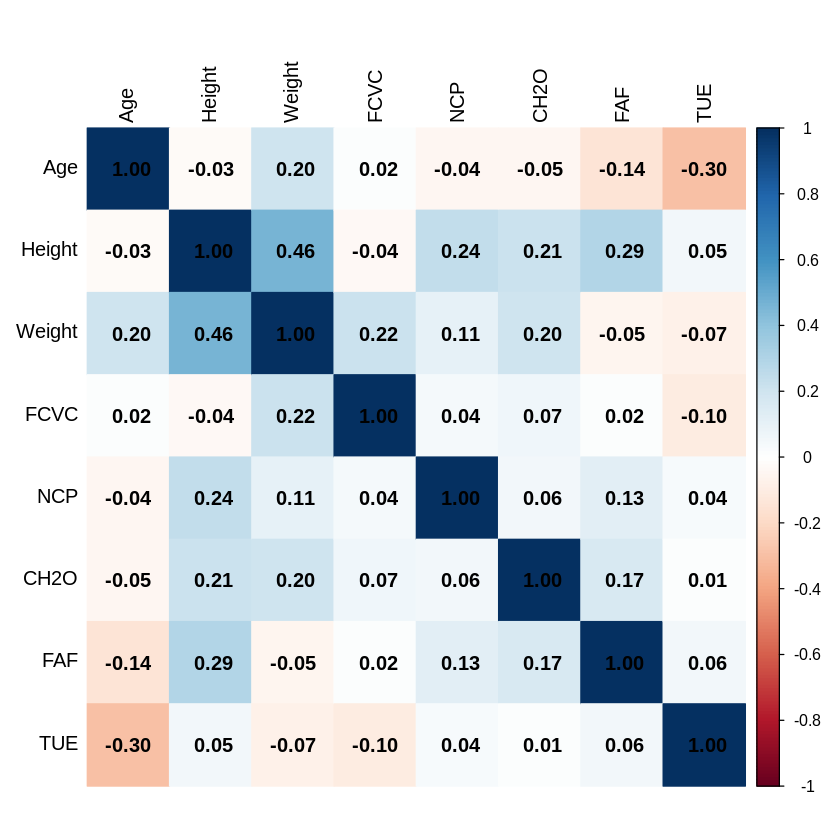

In [ ]:
library(corrplot)
numeric_data <- dataset %>% select(where(is.numeric))
cor_matrix <- cor(numeric_data, use = "complete.obs")
corrplot(cor_matrix, method = "color",
         addCoef.col = "black", tl.col = "black")

Z macierzy wynika, że wzrost i waga są ze sobą umiarkowanie dodatnio skorelowane (0.46), co jest logiczne – wyżsi ludzie zwykle ważą więcej. <br>
Wiek i TUE (czas korzystania z urządzeń elektronicznych) mają umiarkowaną ujemną korelację (–0.30), co może sugerować, że młodsze osoby częściej korzystają z technologii. Podobną, ale dodatnią korelację ma wzrost i częstość aktywności fizycznej, więc można wnioskować, że wyżsi ludzie trochę częściej uprawiają sport. <br>
Większość pozostałych korelacji jest bardzo niska, co wskazuje na niewielką współzależność pomiędzy badanymi zmiennymi liczbowymi.

## **Modele**

### **XGBoost**

Pierwszym wykorzystanym w analizie algorytmem jest XGBoost. Na początku usunięta zostaje zmienna docelowa NObeyesdad ze zbioru cech. Następnie przeprowadzone zostaje kodowanie zmiennych kategorycznych metodą dummy encoding i dane zostają podzielone na zbiór treningowy i testowy w proporcji 80/20.
Do wytrenowania używana jest 5-krotna walidacja krzyżowa do optymalizacji hiperparametrów, w tym głębokości drzew, liczby iteracji oraz współczynników subsample i colsample_bytree. Po wytrenowaniu modelu obliczane są macierze pomyłek dla predykcji w walidacji krzyżowej oraz na zbiorze testowym. Później wyznaczane są prawdopodobieństwa dla każdej klasy, co umożliwia wygenerowanie wykresów krzywych ROC metodą one-vs-rest. Następnie obliczone zostają wskaźniki AUC dla każdej klasy osobno, a na koniec macro AUC, czyli średnią AUC niezależną od liczebności klas oraz weighted AUC, czyli średnią ważoną, uwzględniającą proporcje klas w zbiorze testowym.


In [ ]:
library(xgboost)

X <- dataset %>% select(-NObeyesdad)
Y <- dataset$NObeyesdad

dummy <- dummyVars(~ ., data = X)
X_dummy <- predict(dummy, newdata = X)

train_index <- createDataPartition(Y, p = 0.8, list = FALSE)

X_train <- X_dummy[train_index, ]
Y_train <- Y[train_index]

X_test <- X_dummy[-train_index, ]
Y_test <- Y[-train_index]

xgb_model <- train(
  x = X_train,
  y = Y_train,
  method = "xgbTree",
  metric = "Accuracy",
  trControl = trainControl(
    method = "cv",
    number = 5,
    savePredictions = "final",
    classProbs = TRUE,
    summaryFunction = multiClassSummary
  ),
  tuneLength = 5,
)

print(xgb_model)


Attaching package: ‘xgboost’


The following object is masked from ‘package:dplyr’:

    slice




Strumieniowane dane wyjściowe obcięte do 5000 ostatnich wierszy.
[10:02:25] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[10:02:28] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[10:02:28] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[10:02:28] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[10:02:28] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[10:02:28] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[10:02:28] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[10:02:28] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[10:02:28] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.

Macierz pomyłek – dane treningowe (walidacja krzyżowa)

In [ ]:
confusionMatrix(xgb_model$pred$pred, xgb_model$pred$obs)

Confusion Matrix and Statistics

                     Reference
Prediction            Insufficient_Weight Normal_Weight Obesity_Type_I
  Insufficient_Weight                 215             1              0
  Normal_Weight                         3           217              0
  Obesity_Type_I                        0             0            277
  Obesity_Type_II                       0             0              0
  Obesity_Type_III                      0             0              0
  Overweight_Level_I                    0            12              1
  Overweight_Level_II                   0             0              3
                     Reference
Prediction            Obesity_Type_II Obesity_Type_III Overweight_Level_I
  Insufficient_Weight               0                0                  0
  Normal_Weight                     0                0                 13
  Obesity_Type_I                    3                0                  0
  Obesity_Type_II                 235    

Macierz pomyłek – dane testowe

In [ ]:
pred_prob_xgb <- predict(xgb_model, newdata = X_test, type = "prob")

pred_test_xgb <- predict(xgb_model, newdata = X_test)
confusionMatrix(pred_test_xgb, Y_test)

Confusion Matrix and Statistics

                     Reference
Prediction            Insufficient_Weight Normal_Weight Obesity_Type_I
  Insufficient_Weight                  52             3              0
  Normal_Weight                         2            54              0
  Obesity_Type_I                        0             0             67
  Obesity_Type_II                       0             0              2
  Obesity_Type_III                      0             0              0
  Overweight_Level_I                    0             0              0
  Overweight_Level_II                   0             0              1
                     Reference
Prediction            Obesity_Type_II Obesity_Type_III Overweight_Level_I
  Insufficient_Weight               0                0                  0
  Normal_Weight                     0                0                  3
  Obesity_Type_I                    1                1                  0
  Obesity_Type_II                  58    

Wizualizacja macierzy pomyłek

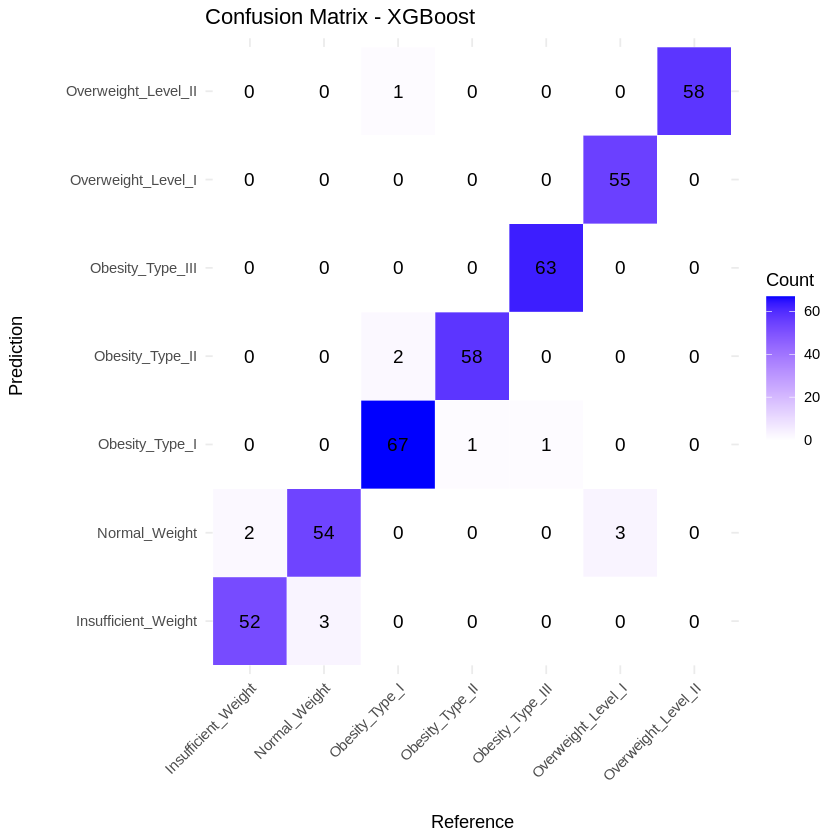

In [ ]:
cm <- confusionMatrix(pred_test_xgb, Y_test)
cm_table <- as.data.frame(cm$table)

ggplot(data = cm_table, aes(x = Reference, y = Prediction, fill = Freq)) +
  geom_tile(color = "white") +
  geom_text(aes(label = Freq), color = "black", size = 4) +
  scale_fill_gradient(low = "white", high = "blue") +
  labs(title = "Confusion Matrix - XGBoost", fill = "Count") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

Krzywe ROC (One-vs-Rest) i wartości AUC dla poszczególnych klas

Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var


Setting direction: controls < cases

Setting direction: controls < cases

Setting direction: controls < cases

Setting direction: controls < cases

Setting direction: controls < cases

Setting direction: controls < cases

Setting direction: controls < cases



AUC for Insufficient_Weight : 0.9993928 
AUC for Normal_Weight : 0.9960369 
AUC for Obesity_Type_I : 0.9984082 
AUC for Obesity_Type_II : 0.9995774 
AUC for Obesity_Type_III : 1 
AUC for Overweight_Level_I : 0.994999 
AUC for Overweight_Level_II : 0.9997619 


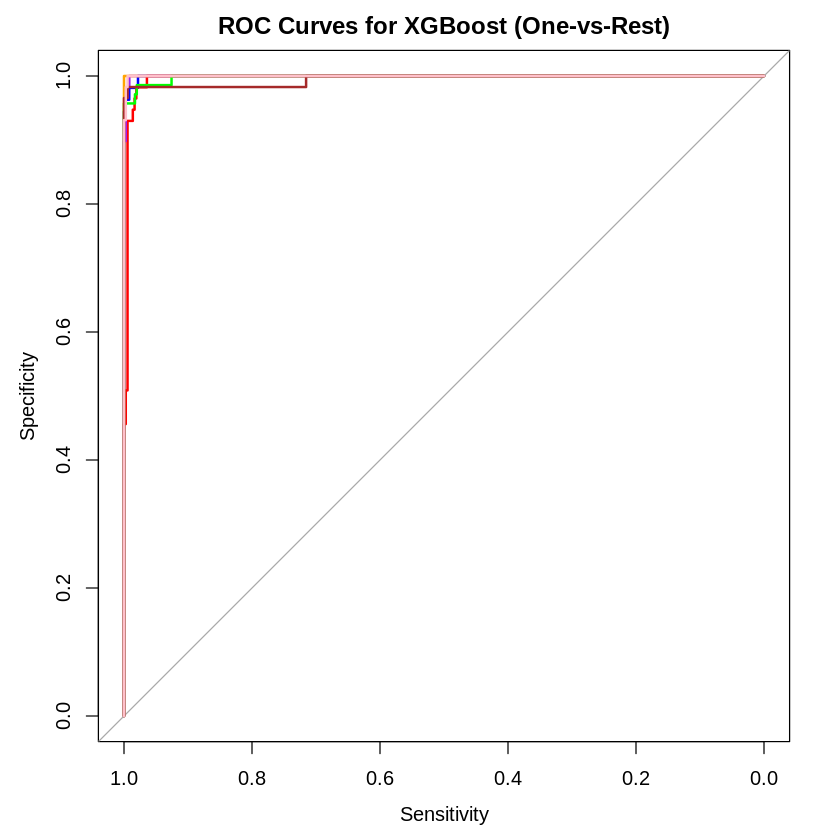

In [ ]:
library(pROC)

probabilities <- predict(xgb_model, newdata = X_test, type = "prob")

roc_curves_xgb <- list()
classes <- levels(Y_test)
for (class in classes) {
  binary_labels <- as.numeric(Y_test == class)
  roc_curve <- roc(binary_labels, probabilities[, class], levels = c(0, 1))
  roc_curves_xgb[[class]] <- roc_curve
}

colors <- c("blue", "red", "green", "purple", "orange", "brown", "pink")
plot(roc_curves_xgb[[1]], col = colors[1], main = "ROC Curves for XGBoost (One-vs-Rest)",
     xlab = "Sensitivity", ylab = "Specificity")
for (i in 2:length(classes)) {
  lines(roc_curves_xgb[[i]], col = colors[i])
}

for (class in classes) {
  auc_value <- auc(roc_curves_xgb[[class]])
  cat("AUC for", class, ":", auc_value, "\n")
}

Średnie wartości AUC

In [ ]:
auc_values <- sapply(roc_curves_xgb, auc)

macro_auc_xgb <- mean(auc_values)

weights <- prop.table(table(Y_test))
weighted_auc_xgb <- sum(auc_values * weights[names(auc_values)])

cat("Macro AUC:", round(macro_auc_xgb, 4), "\n")
cat("Weighted AUC:", round(weighted_auc_xgb, 4), "\n")

Macro AUC: 0.9983 
Weighted AUC: 0.9983 


**Najlepsze wyniki uzyskane zostały dla modelu o parametrach:** <br>
nrounds = 100,
<br> max_depth = 3,
<br> eta = 0.4,
<br> colsample_bytree = 0.8,
<br> min_child_weight = 1,
<br> subsample = 0.875.

**Na zbiorze treningowym**, w walidacji krzyżowej, model osiągnął dokładność **97%**, a **na zbiorze testowym** – **96,9%**. Taka wartość, przy bardzo zbliżonych rezultatach między trenowaniem a testowaniem, świadczy o dobrej generalizacji i braku przeuczenia.


Szczegółowa analiza macierzy pomyłek pokazuje, że model najlepiej radzi sobie z rozpoznawaniem klasy Overweight_Level_II – osiągnęła ona 100% czułości, co oznacza, że model nie popełnił ani jednego błędu w jej klasyfikacji.


Większość pomyłek miała miejsce pomiędzy klasami, które sąsiadują ze sobą, patrząc na wykres zależności wagi względem wzrostu – np. Normal_Weight i Overweight_Level_I lub Normal_Weight i Insufficient_Weight. Mimo to, wszystkie klasy osiągnęły bardzo wysokie wartości F1-score i balanced accuracy, co wskazuje na stabilność modelu.


Równie dobre są wyniki AUC dla klasyfikacji typu one-vs-rest – **wszystkie klasy osiągnęły wartości powyżej 0,994**. **Macro AUC i Weighted AUC** wyniosły **0,9983**, co oznacza, że model bardzo dobrze rozpoznaje wszystkie poziomy otyłości, więc jest dobry do ich przewidywania.


### **Drzewo decyzyjne**

Drugim testowanym algorytmem jest klasyczny model drzewa decyzyjnego, oparty na implementacji rpart. Zbiór został przygotowany w taki sam sposób jak przy algorytmie XGBoost. Następnie przetestowano różne hiperparametry (cp oraz maxdepth). Dla każdego poziomu głębokości wyszukiwano najlepszy cp metodą 5-krotnej walidacji krzyżowej. Model o najwyższej dokładności został następnie ponownie wytrenowany z wybranymi parametrami.



In [ ]:
library(rpart)

X <- dataset %>% select(-NObeyesdad)
Y <- dataset$NObeyesdad

dummy <- dummyVars(~ ., data = X)
X_dummy <- predict(dummy, newdata = X)

nzv <- nearZeroVar(X_dummy, saveMetrics = TRUE)
X_dummy <- X_dummy[, !nzv$nzv]

train_index <- createDataPartition(Y, p = 0.8, list = FALSE)
X_train <- X_dummy[train_index, ]
Y_train <- Y[train_index]
X_test <- X_dummy[-train_index, ]
Y_test <- Y[-train_index]

cp_values <- seq(0.001, 0.05, by = 0.005)
depth_values <- 2:15
results <- data.frame()

for (depth in depth_values) {
  set.seed(123)
  model <- train(
    x = X_train,
    y = Y_train,
    method = "rpart",
    metric = "Accuracy",
    preProcess = c("center", "scale"),
    trControl = trainControl(
      method = "cv",
      number = 5,
      savePredictions = "final",
      classProbs = TRUE,
      summaryFunction = multiClassSummary),
    tuneGrid = expand.grid(cp = cp_values),
    control = rpart.control(maxdepth = depth)
  )

  best <- model$results[which.max(model$results$Accuracy), ]
  best$maxdepth <- depth
  results <- rbind(results, best)
}

results <- results %>% arrange(desc(Accuracy))
print(results)

best_cp <- results$cp[1]
best_depth <- results$maxdepth[1]

set.seed(123)
final_tree <- train(
  x = X_train,
  y = Y_train,
  method = "rpart",
  metric = "Accuracy",
  trControl = trainControl(
    method = "cv",
    number = 5,
    savePredictions = "final",
    classProbs = TRUE,
    summaryFunction = multiClassSummary),
  tuneGrid = data.frame(cp = best_cp),
  control = rpart.control(maxdepth = best_depth)
)

Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :

      cp   logLoss       AUC      prAUC  Accuracy     Kappa   Mean_F1
1  0.001 0.6755744 0.9795220 0.55439841 0.8988278 0.8818134 0.8961858
2  0.001 0.6755744 0.9795220 0.55439841 0.8988278 0.8818134 0.8961858
3  0.001 0.6755744 0.9795220 0.55439841 0.8988278 0.8818134 0.8961858
4  0.001 0.6755744 0.9795220 0.55439841 0.8988278 0.8818134 0.8961858
5  0.001 0.6755744 0.9795220 0.55439841 0.8988278 0.8818134 0.8961858
6  0.001 0.6755744 0.9795220 0.55439841 0.8988278 0.8818134 0.8961858
7  0.001 0.6753083 0.9794748 0.55662056 0.8982360 0.8811222 0.8957747
8  0.001 0.6773800 0.9794631 0.55421507 0.8982325 0.8811182 0.8957033
9  0.001 0.6934729 0.9757681 0.52381807 0.8763753 0.8555828 0.8731135
10 0.001 0.6503060 0.9742019 0.49719194 0.8669393 0.8445830 0.8635347
11 0.001 0.6679566 0.9613433 0.44092982 0.8142629 0.7827877 0.8068411
12 0.001 0.7306906 0.9436544 0.34578610 0.7633812 0.7239478 0.7612063
13 0.001 0.8288657 0.9171131 0.18323321 0.6320659 0.5676767       NaN
14 0.001 0.9828714 0

Wizualizacja drzewa

CART 

1691 samples
  20 predictor
   7 classes: 'Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II' 

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 1350, 1355, 1354, 1353, 1352 
Resampling results:

  logLoss    AUC       prAUC      Accuracy   Kappa      Mean_F1  
  0.6755744  0.979522  0.5543984  0.8988278  0.8818134  0.8961858
  Mean_Sensitivity  Mean_Specificity  Mean_Pos_Pred_Value  Mean_Neg_Pred_Value
  0.8962616         0.9831693         0.8984406            0.9832662          
  Mean_Precision  Mean_Recall  Mean_Detection_Rate  Mean_Balanced_Accuracy
  0.8984406       0.8962616    0.128404             0.9397154             

Tuning parameter 'cp' was held constant at a value of 0.001


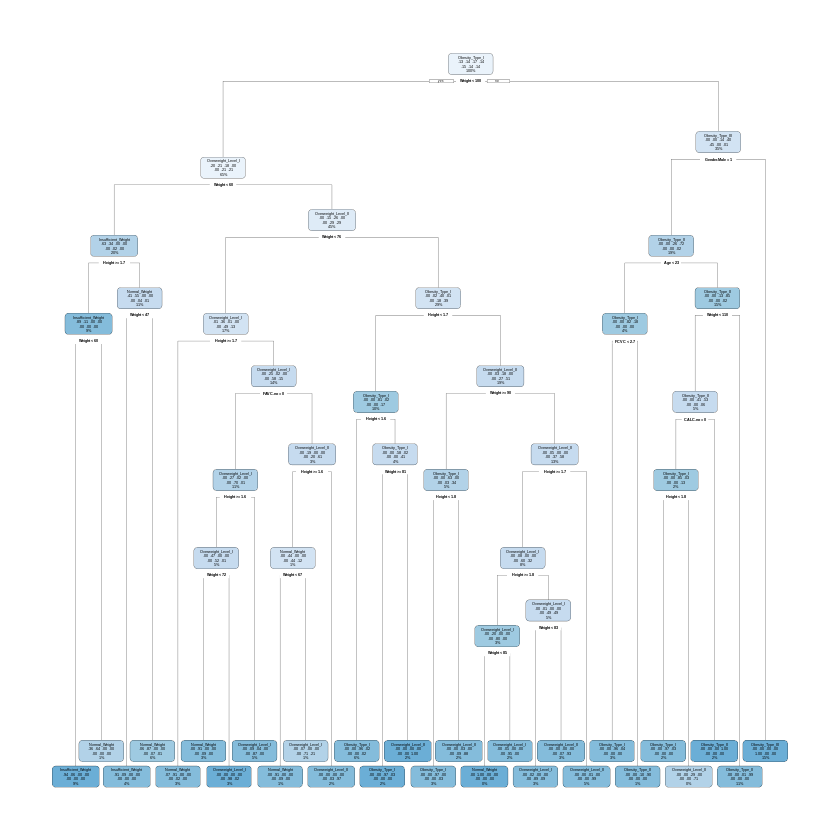

In [ ]:
library(rpart.plot)

rpart.plot(final_tree$finalModel, box.palette = "Blues")
print(final_tree)

Macierz pomyłek – dane treningowe (walidacja krzyżowa)

In [ ]:
confusionMatrix(final_tree$pred$pred, final_tree$pred$obs)

Confusion Matrix and Statistics

                     Reference
Prediction            Insufficient_Weight Normal_Weight Obesity_Type_I
  Insufficient_Weight                 204            20              0
  Normal_Weight                        14           182              0
  Obesity_Type_I                        0             0            261
  Obesity_Type_II                       0             0              4
  Obesity_Type_III                      0             0              0
  Overweight_Level_I                    0            26              4
  Overweight_Level_II                   0             2             12
                     Reference
Prediction            Obesity_Type_II Obesity_Type_III Overweight_Level_I
  Insufficient_Weight               0                0                  0
  Normal_Weight                     0                0                 27
  Obesity_Type_I                   13                0                  0
  Obesity_Type_II                 224    

Macierz pomyłek – dane testowe

In [ ]:
pred_test_tree <- predict(final_tree, newdata = X_test)
confusionMatrix(pred_test_tree, Y_test)

Confusion Matrix and Statistics

                     Reference
Prediction            Insufficient_Weight Normal_Weight Obesity_Type_I
  Insufficient_Weight                  47             3              0
  Normal_Weight                         7            50              0
  Obesity_Type_I                        0             0             70
  Obesity_Type_II                       0             0              0
  Obesity_Type_III                      0             0              0
  Overweight_Level_I                    0             4              0
  Overweight_Level_II                   0             0              0
                     Reference
Prediction            Obesity_Type_II Obesity_Type_III Overweight_Level_I
  Insufficient_Weight               0                0                  0
  Normal_Weight                     0                0                  5
  Obesity_Type_I                    4                0                  0
  Obesity_Type_II                  55    

Wizualizacja macierzy pomyłek

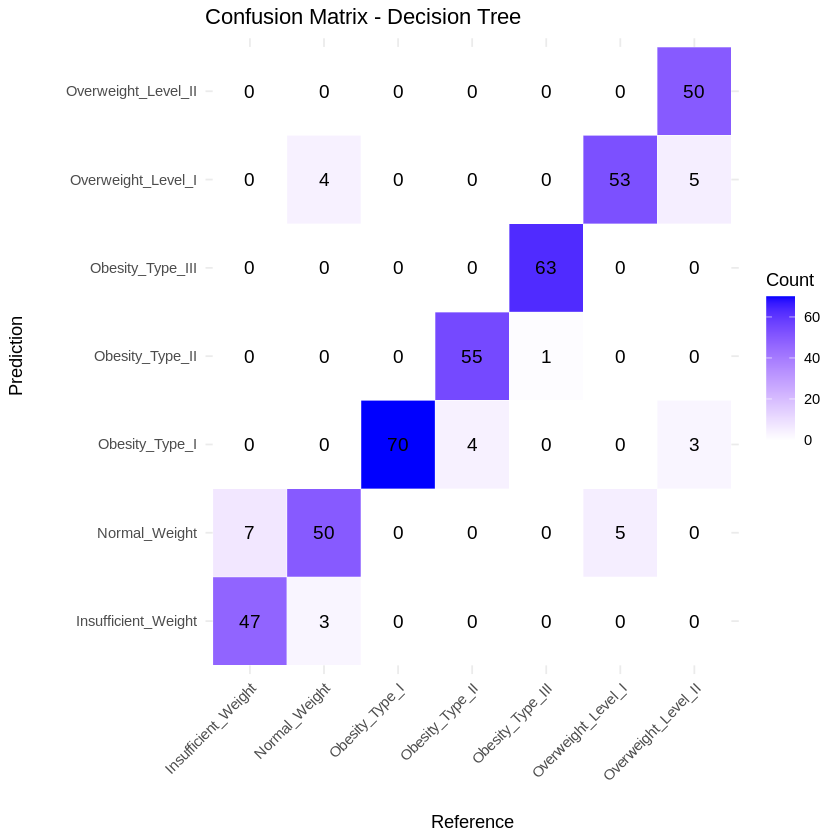

In [ ]:
cm <- confusionMatrix(pred_test_tree, Y_test)
cm_table <- as.data.frame(cm$table)

ggplot(data = cm_table, aes(x = Reference, y = Prediction, fill = Freq)) +
  geom_tile(color = "white") +
  geom_text(aes(label = Freq), color = "black", size = 4) +
  scale_fill_gradient(low = "white", high = "blue") +
  labs(title = "Confusion Matrix - Decision Tree", fill = "Count") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

Krzywe ROC (One-vs-Rest) i wartości AUC dla poszczególnych klas

Setting direction: controls < cases

Setting direction: controls < cases

Setting direction: controls < cases

Setting direction: controls < cases

Setting direction: controls < cases

Setting direction: controls < cases

Setting direction: controls < cases



AUC for Insufficient_Weight : 0.9919045 
AUC for Normal_Weight : 0.9696728 
AUC for Obesity_Type_I : 0.9929796 
AUC for Obesity_Type_II : 0.9949059 
AUC for Obesity_Type_III : 0.9921875 
AUC for Overweight_Level_I : 0.9807821 
AUC for Overweight_Level_II : 0.9926653 


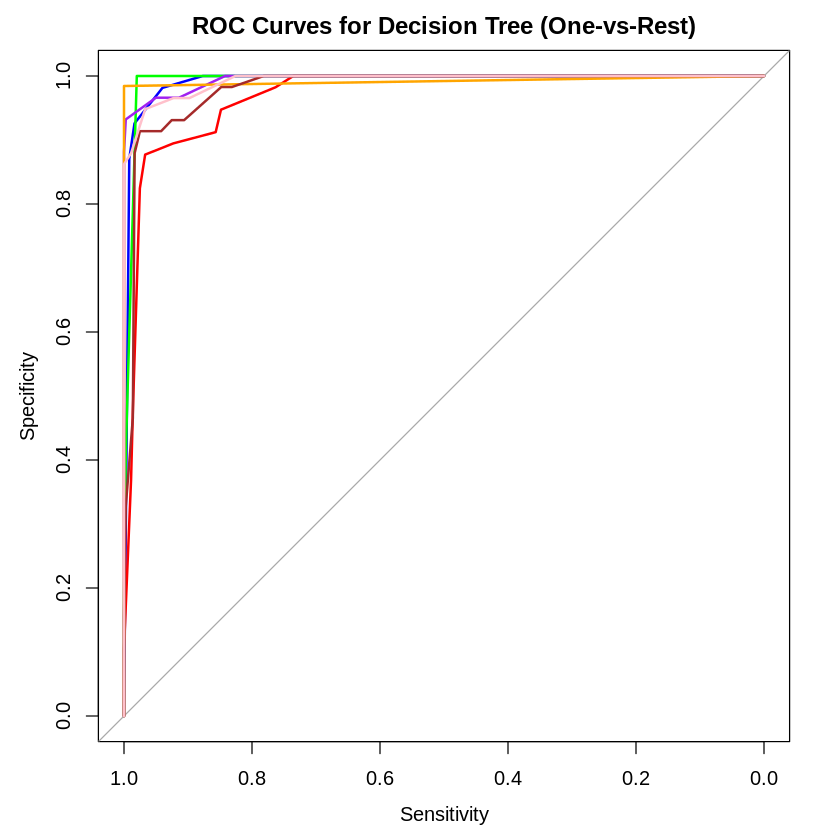

In [ ]:
pred_prob_tree <- predict(final_tree, newdata = X_test, type = "prob")

classes <- levels(Y_test)
roc_curves_tree <- list()

for (class in classes) {
  binary_labels <- as.numeric(Y_test == class)
  roc_curve <- roc(binary_labels, pred_prob_tree[, class], levels = c(0, 1))
  roc_curves_tree[[class]] <- roc_curve
}

colors <- c("blue", "red", "green", "purple", "orange", "brown", "pink")

plot(roc_curves_tree[[1]], col = colors[1], main = "ROC Curves for Decision Tree (One-vs-Rest)",
     xlab = "Sensitivity", ylab = "Specificity")
for (i in 2:length(classes)) {
  lines(roc_curves_tree[[i]], col = colors[i])
}

for (class in classes) {
  auc_value <- auc(roc_curves_tree[[class]])
  cat("AUC for", class, ":", auc_value, "\n")
}

Średnie wartości AUC

In [ ]:
auc_values <- sapply(roc_curves_tree, auc)
macro_auc_tree <- mean(auc_values)

weights <- prop.table(table(Y_test))
weighted_auc_tree <- sum(auc_values * weights)

cat("Macro AUC:", round(macro_auc_tree, 4), "\n")
cat("Weighted AUC:", round(weighted_auc_tree, 4), "\n")

Macro AUC: 0.9879 
Weighted AUC: 0.9881 


**Najlepsze wyniki uzyskano dla drzewa decyzyjnego o parametrach**: <br> cp = 0.001 <br> maxdepth = 10

Pomimo tego, że drzewo było stosunkowo głębokie, dalsze przycinanie prowadziło do obniżenia skuteczności klasyfikacji, dlatego zostało pozostawione w takiej formie.


W **walidacji krzyżowej** model osiągnął dokładność **89,8%**, a **na zbiorze testowym 92,38%**, co świadczy o dobrej generalizacji.


Model najlepiej rozpoznaje klasę Obesity_Type_I – uzyskała ona 100% czułości, co oznacza brak błędów klasyfikacji. Bardzo dobrze wypadła też klasa Obesity_Type_III (czułość: 98,44%).  


Trochę słabsze wyniki uzyskały klasy Overweight_Level_I (czułość: 77,6%) oraz Overweight_Level_II (czułość: 89,7%), które były czasem mylone ze sobą oraz Normal_Weight i Obesity_Type_I.


Krzywe ROC również wskazują na wysoką skuteczność klasyfikatora. Dla większości klas **wartości AUC przekraczały 0,98**. Średnie wartości **macro AUC = 0.9879** i **weighted AUC = 0.9881** potwierdzają, że model dobrze radzi sobie z klasyfikacją wszystkich kategorii.


### **Random forest**

Kolejnym modelem wykorzystanym w analizie był Random Forest - losowy las decyzyjny. Przed rozpoczęciem treningu dokonano kodowania zmiennych kategorycznych metodą one-hot encoding, a następnie podzielono dane na zbiór treningowy i testowy w proporcji 80/20. Model został wytrenowany z użyciem domyślnych hiperparametrów z 5-krotną walidacją krzyżową. Po wytrenowaniu modelu obliczono macierze pomyłek zarówno dla wyników walidacji, jak i na danych testowych.



In [ ]:
library(randomForest)

X <- dataset %>% select(-NObeyesdad)
Y <- dataset$NObeyesdad

dummy <- dummyVars(~ ., data = X)
X_dummy <- predict(dummy, newdata = X)

train_index <- createDataPartition(Y, p = 0.8, list = FALSE)
X_train <- X_dummy[train_index, ]
Y_train <- Y[train_index]
X_test <- X_dummy[-train_index, ]
Y_test <- Y[-train_index]

rf_model <- train(
  x = X_train,
  y = Y_train,
  method = "rf",
  metric = "Accuracy",
  trControl = trainControl(
    method = "cv",
    number = 5,
    savePredictions = "final",
    classProbs = TRUE,
    summaryFunction = multiClassSummary
  ),
  tuneLength = 5
)

print(rf_model)

randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:ggplot2’:

    margin


The following object is masked from ‘package:dplyr’:

    combine




Random Forest 

1691 samples
  31 predictor
   7 classes: 'Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II' 

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 1353, 1352, 1353, 1351, 1355 
Resampling results across tuning parameters:

  mtry  logLoss    AUC        prAUC      Accuracy   Kappa      Mean_F1  
   2    0.6908171  0.9782641  0.8612390  0.8261311  0.7967679  0.8231548
   9    0.2510632  0.9969445  0.8452483  0.9485601  0.9399218  0.9474562
  16    0.1906337  0.9981744  0.8147336  0.9586037  0.9516487  0.9575420
  23    0.1612175  0.9984958  0.7671632  0.9597907  0.9530333  0.9586600
  31    0.1687833  0.9972302  0.6888982  0.9485550  0.9399023  0.9468914
  Mean_Sensitivity  Mean_Specificity  Mean_Pos_Pred_Value  Mean_Neg_Pred_Value
  0.8239093         0.9709218         0.8377210            0.9714429          
  0.9472536         0.9914634         0.949479

Macierz pomyłek – dane treningowe (walidacja krzyżowa)

In [ ]:
confusionMatrix(rf_model$pred$pred, rf_model$pred$obs)

Confusion Matrix and Statistics

                     Reference
Prediction            Insufficient_Weight Normal_Weight Obesity_Type_I
  Insufficient_Weight                 215             7              0
  Normal_Weight                         3           208              0
  Obesity_Type_I                        0             0            275
  Obesity_Type_II                       0             0              1
  Obesity_Type_III                      0             0              0
  Overweight_Level_I                    0            15              2
  Overweight_Level_II                   0             0              3
                     Reference
Prediction            Obesity_Type_II Obesity_Type_III Overweight_Level_I
  Insufficient_Weight               0                0                  0
  Normal_Weight                     0                0                 14
  Obesity_Type_I                    3                0                  0
  Obesity_Type_II                 234    

Macierz pomyłek – dane testowe

In [ ]:
pred_test_rf <- predict(rf_model, newdata = X_test)
confusionMatrix(pred_test_rf, Y_test)

Confusion Matrix and Statistics

                     Reference
Prediction            Insufficient_Weight Normal_Weight Obesity_Type_I
  Insufficient_Weight                  52             1              0
  Normal_Weight                         2            54              0
  Obesity_Type_I                        0             0             66
  Obesity_Type_II                       0             0              2
  Obesity_Type_III                      0             0              0
  Overweight_Level_I                    0             2              0
  Overweight_Level_II                   0             0              2
                     Reference
Prediction            Obesity_Type_II Obesity_Type_III Overweight_Level_I
  Insufficient_Weight               0                0                  0
  Normal_Weight                     0                0                  4
  Obesity_Type_I                    1                0                  0
  Obesity_Type_II                  58    

Wizualizacja macierzy pomyłek

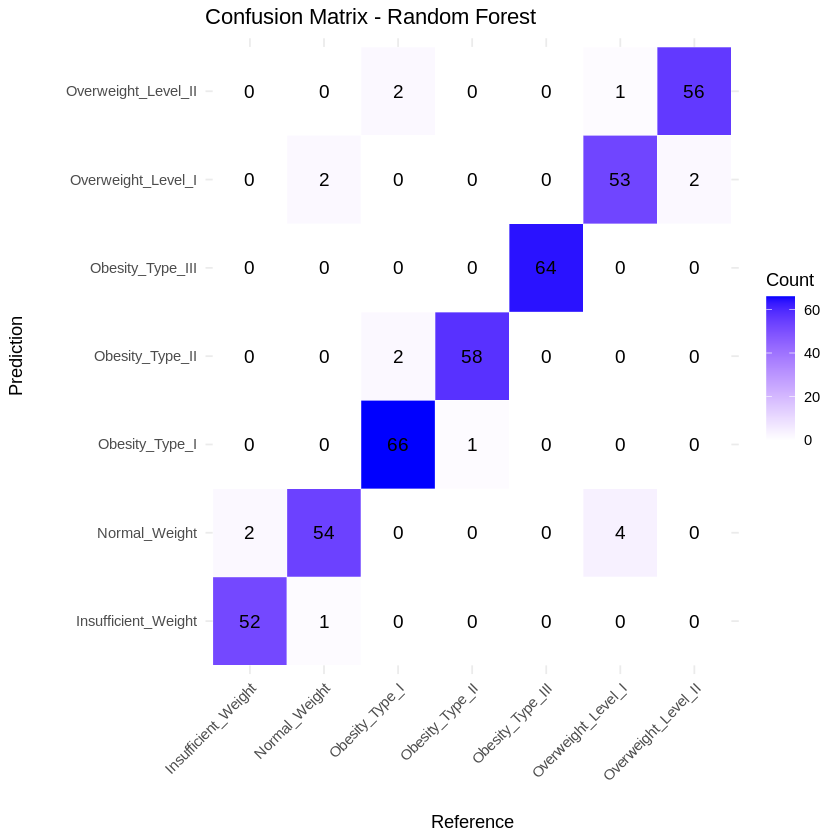

In [ ]:
cm <- confusionMatrix(pred_test_rf, Y_test)
cm_table <- as.data.frame(cm$table)

ggplot(data = cm_table, aes(x = Reference, y = Prediction, fill = Freq)) +
  geom_tile(color = "white") +
  geom_text(aes(label = Freq), color = "black", size = 4) +
  scale_fill_gradient(low = "white", high = "blue") +
  labs(title = "Confusion Matrix - Random Forest", fill = "Count") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

Krzywe ROC (One-vs-Rest) i wartości AUC dla poszczególnych klas

Setting direction: controls < cases

Setting direction: controls < cases

Setting direction: controls < cases

Setting direction: controls < cases

Setting direction: controls < cases

Setting direction: controls < cases

Setting direction: controls < cases



AUC for Insufficient_Weight : 0.9997976 
AUC for Normal_Weight : 0.9979218 
AUC for Obesity_Type_I : 0.9986531 
AUC for Obesity_Type_II : 0.9994366 
AUC for Obesity_Type_III : 1 
AUC for Overweight_Level_I : 0.9982378 
AUC for Overweight_Level_II : 0.9991427 


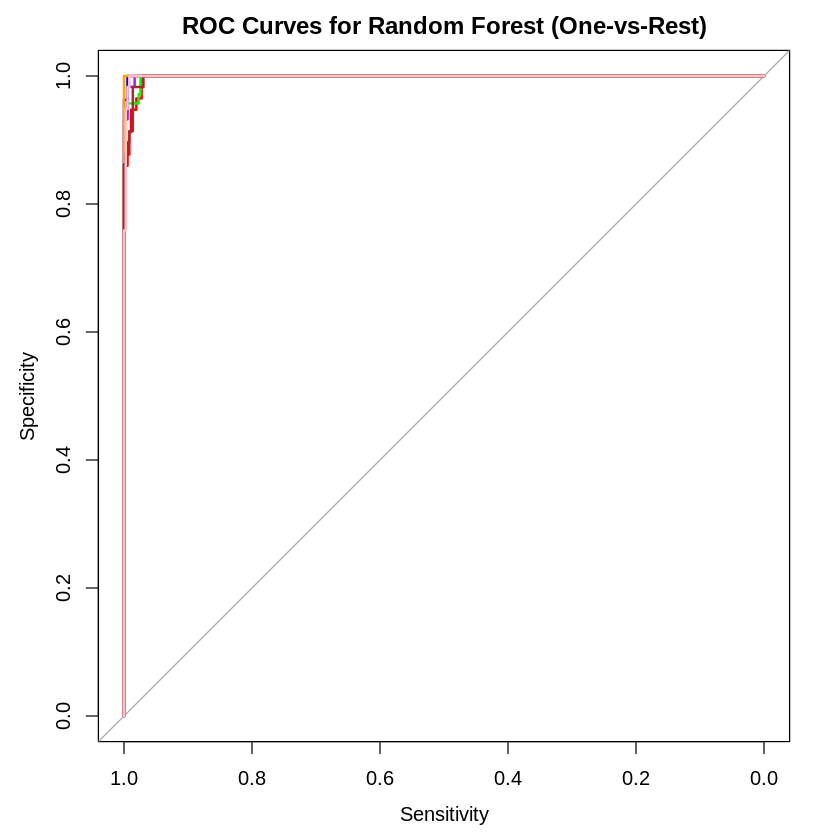

In [ ]:
pred_prob_rf <- predict(rf_model, newdata = X_test, type = "prob")

classes <- levels(Y_test)
roc_curves_rf <- list()

for (class in classes) {
  binary_labels <- as.numeric(Y_test == class)
  roc_curve <- roc(binary_labels, pred_prob_rf[, class], levels = c(0, 1))
  roc_curves_rf[[class]] <- roc_curve
}

colors <- c("blue", "red", "green", "purple", "orange", "brown", "pink")

plot(roc_curves_rf[[1]], col = colors[1], main = "ROC Curves for Random Forest (One-vs-Rest)",
     xlab = "Sensitivity", ylab = "Specificity")
for (i in 2:length(classes)) {
  lines(roc_curves_rf[[i]], col = colors[i])
}

for (class in classes) {
  auc_value <- auc(roc_curves_rf[[class]])
  cat("AUC for", class, ":", auc_value, "\n")
}

Średnie wartości AUC

In [ ]:
auc_values_rf <- sapply(roc_curves_rf, auc)

macro_auc_rf <- mean(auc_values_rf)

weights_rf <- prop.table(table(Y_test))
weighted_auc_rf <- sum(auc_values_rf * weights_rf[names(auc_values_rf)])

cat("Macro AUC:", round(macro_auc_rf, 4), "\n")
cat("Weighted AUC:", round(weighted_auc_rf, 4), "\n")

Macro AUC: 0.999 
Weighted AUC: 0.999 


**Najlepsze wyniki uzyskano dla modelu Random Forest z mtry = 23.**

W **walidacji krzyżowej** model osiągnął dokładność **95,98%**, natomiast na **zbiorze testowym** – **95,95%**.


Analiza macierzy pomyłek pokazała, że model praktycznie bezbłędnie klasyfikuje klasy Obesity_Type_III i Obesity_Type_II. Bardzo dobre wyniki uzyskano również dla klasy Insufficient_Weight (czułość: 96,3%, precyzja: 99,45%).


Analiza krzywych ROC wykazała bardzo wysoką skuteczność modelu – **wartości AUC dla każdej klasy przekroczyły 0,99**, a dla klasy Obesity_Type_III AUC wyniosło dokładnie 1. Ostateczne wskaźniki – **macro AUC i weighted AUC osiągnęły wartość 0,999**, co oznacza, że model bardzo precyzyjnie rozróżnia wszystkie poziomy otyłości. Dzięki temu Random Forest jest bardzo skuteczny i odporny na błędy.


### **SVM**

Kolejnym wykorzystanym modelem był model SVM. Na początku zakodowano zmienne kategoryczne za pomocą one-hot encodingu przy użyciu funkcji dummyVars(), a następnie usunięto zmienne o zerowej lub bliskiej zeru wariancji, żeby uniknąć szumów. Dane zostały następnie podzielone na zbiór treningowy i testowy w proporcji 80/20. <br>
Model SVM był trenowany z 5-krotną walidacją krzyżową i standaryzacją cech (center i scale). W celu znalezienia najlepszych hiperparametrów zastosowano siatkę różnych parametrów, dla każdej wartości sigma trenowano modele z różnymi C, a następnie wybrano najlepszy zestaw parametrów na podstawie accuracy osiągniętej podczas walidacji. Po wybraniu najlepszego zestawu parametrów zbudowano końcowy model i obliczono macierze pomyłek zarówno dla danych walidacyjnych, jak i testowych.

In [ ]:
library(kernlab)

X <- dataset %>% select(-NObeyesdad)
Y <- dataset$NObeyesdad

dummy <- dummyVars(~ ., data = X)
X_dummy <- predict(dummy, newdata = X)

nzv <- nearZeroVar(X_dummy, saveMetrics = TRUE)
X_dummy <- X_dummy[, !nzv$nzv]

train_index <- createDataPartition(Y, p = 0.8, list = FALSE)
X_train <- X_dummy[train_index, ]
Y_train <- Y[train_index]
X_test <- X_dummy[-train_index, ]
Y_test <- Y[-train_index]

sigma_values <- c(0.005, 0.0075, 0.01, 0.0125, 0.015)
C_values <- c(16, 32, 64, 100, 200, 500, 1000)
results <- data.frame()

for (s in sigma_values) {
  svm_model <- train(
    x = X_train,
    y = Y_train,
    method = "svmRadial",
    metric = "Accuracy",
    preProcess = c("center", "scale"),
    trControl = trainControl(method = "cv",
                             number = 5,
                             savePredictions = "final",
                             classProbs = TRUE,
                             summaryFunction = multiClassSummary),
    tuneGrid = expand.grid(sigma = s, C = C_values)
  )
  best <- svm_model$results[which.max(svm_model$results$Accuracy), ]
  results <- rbind(results, best)
}

results <- results %>% arrange(desc(Accuracy))
print(results)

best_sigma <- results$sigma[1]
best_C <- results$C[1]
print(best_sigma)
print(best_C)

final_svm_model <- train(
  x = X_train,
  y = Y_train,
  method = "svmRadial",
  metric = "Accuracy",
  preProcess = c("center", "scale"),
  tuneGrid = data.frame(sigma = best_sigma, C = best_C),
  trControl = trainControl(
    method = "cv",
    number = 5,
    savePredictions = "final",
    classProbs = TRUE,
    summaryFunction = multiClassSummary,
  )
)

print(final_svm_model)


Attaching package: ‘kernlab’


The following object is masked from ‘package:ggplot2’:

    alpha


Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”


    sigma    C   logLoss       AUC     prAUC  Accuracy     Kappa Mean_F1
5  0.0050  200 0.6237175 0.9840876 0.8921282 0.8178509 0.7871415     NaN
51 0.0075  200 0.6350589 0.9835682 0.8895605 0.8148965 0.7837289     NaN
52 0.0100  200 0.6430431 0.9830041 0.8883749 0.8113543 0.7795521     NaN
7  0.0125 1000 0.6563863 0.9812628 0.8824291 0.8054757 0.7727416     NaN
53 0.0150  200 0.6735007 0.9798633 0.8792659 0.8037131 0.7706630     NaN
   Mean_Sensitivity Mean_Specificity Mean_Pos_Pred_Value Mean_Neg_Pred_Value
5         0.8112416        0.9697197                 NaN           0.9726950
51        0.8091064        0.9692328                 NaN           0.9721529
52        0.8047397        0.9686374                 NaN           0.9716501
7         0.7996153        0.9676716                 NaN           0.9705617
53        0.7975737        0.9673744                 NaN           0.9703083
   Mean_Precision Mean_Recall Mean_Detection_Rate Mean_Balanced_Accuracy
5             NaN   0.81124

Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”


Support Vector Machines with Radial Basis Function Kernel 

1691 samples
  20 predictor
   7 classes: 'Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II' 

Pre-processing: centered (20), scaled (20) 
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 1352, 1352, 1353, 1353, 1354 
Resampling results:

  logLoss    AUC        prAUC      Accuracy   Kappa      Mean_F1
  0.6320193  0.9824356  0.8850337  0.8125476  0.7809528  NaN    
  Mean_Sensitivity  Mean_Specificity  Mean_Pos_Pred_Value  Mean_Neg_Pred_Value
  0.8063168         0.9688315         NaN                  0.9717733          
  Mean_Precision  Mean_Recall  Mean_Detection_Rate  Mean_Balanced_Accuracy
  NaN             0.8063168    0.1160782            0.8875741             

Tuning parameter 'sigma' was held constant at a value of 0.005
Tuning
 parameter 'C' was held constant at a value of 200


Macierz pomyłek – dane treningowe (walidacja krzyżowa)

In [ ]:
confusionMatrix(final_svm_model$pred$pred, final_svm_model$pred$obs)

Confusion Matrix and Statistics

                     Reference
Prediction            Insufficient_Weight Normal_Weight Obesity_Type_I
  Insufficient_Weight                 210             9              0
  Normal_Weight                         8           221              0
  Obesity_Type_I                        0             0            264
  Obesity_Type_II                       0             0              0
  Obesity_Type_III                      0             0              0
  Overweight_Level_I                    0             0              0
  Overweight_Level_II                   0             0             17
                     Reference
Prediction            Obesity_Type_II Obesity_Type_III Overweight_Level_I
  Insufficient_Weight               0                0                  0
  Normal_Weight                     0                0                144
  Obesity_Type_I                    2                0                  3
  Obesity_Type_II                 234    

Macierz pomyłek - dane testowe

In [ ]:
pred_test_svm <- predict(final_svm_model, newdata = X_test)
confusionMatrix(pred_test_svm, Y_test)

Confusion Matrix and Statistics

                     Reference
Prediction            Insufficient_Weight Normal_Weight Obesity_Type_I
  Insufficient_Weight                  52             1              0
  Normal_Weight                         2            55              0
  Obesity_Type_I                        0             0             68
  Obesity_Type_II                       0             0              0
  Obesity_Type_III                      0             0              0
  Overweight_Level_I                    0             0              0
  Overweight_Level_II                   0             1              2
                     Reference
Prediction            Obesity_Type_II Obesity_Type_III Overweight_Level_I
  Insufficient_Weight               0                0                  0
  Normal_Weight                     0                0                 38
  Obesity_Type_I                    1                0                  2
  Obesity_Type_II                  58    

Wizualizacja macierzy pomyłek

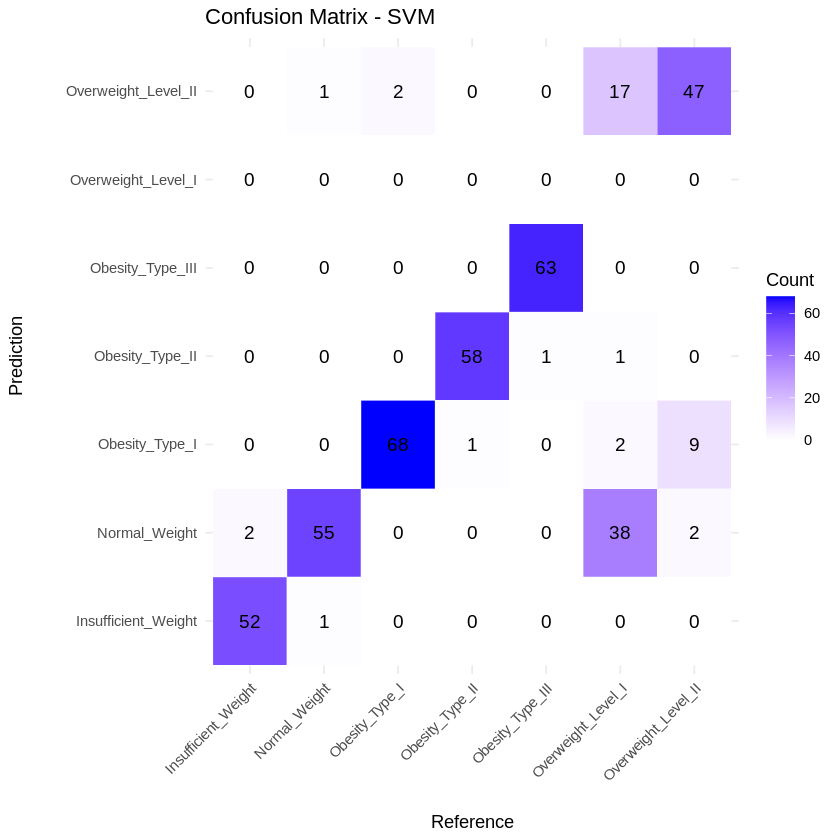

In [ ]:
cm <- confusionMatrix(pred_test_svm, Y_test)
cm_table <- as.data.frame(cm$table)

ggplot(data = cm_table, aes(x = Reference, y = Prediction, fill = Freq)) +
  geom_tile(color = "white") +
  geom_text(aes(label = Freq), color = "black", size = 4) +
  scale_fill_gradient(low = "white", high = "blue") +
  labs(title = "Confusion Matrix - SVM", fill = "Count") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

Krzywe ROC (One-vs-Rest) i wartości AUC dla poszczególnych klas

Setting direction: controls < cases

Setting direction: controls < cases

Setting direction: controls < cases

Setting direction: controls < cases

Setting direction: controls < cases

Setting direction: controls < cases

Setting direction: controls < cases



AUC for Insufficient_Weight : 0.999494 
AUC for Normal_Weight : 0.9930888 
AUC for Obesity_Type_I : 0.9982857 
AUC for Obesity_Type_II : 0.9975116 
AUC for Obesity_Type_III : 0.9978933 
AUC for Overweight_Level_I : 0.9660412 
AUC for Overweight_Level_II : 0.9608973 


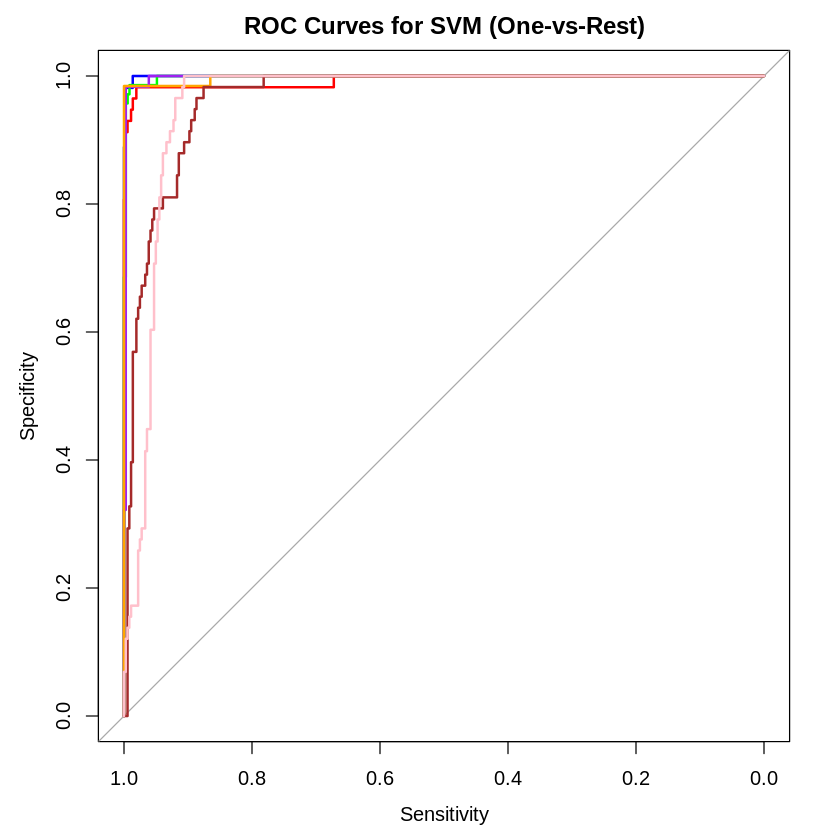

In [ ]:
pred_prob_svm <- predict(final_svm_model, newdata = X_test, type = "prob")

classes <- levels(Y_test)
roc_curves_svm <- list()

for (class in classes) {
  binary_labels <- as.numeric(Y_test == class)
  roc_curve <- roc(binary_labels, pred_prob_svm[, class], levels = c(0, 1))
  roc_curves_svm[[class]] <- roc_curve
}

colors <- c("blue", "red", "green", "purple", "orange", "brown", "pink")

plot(roc_curves_svm[[1]], col = colors[1], main = "ROC Curves for SVM (One-vs-Rest)",
     xlab = "Sensitivity", ylab = "Specificity")
for (i in 2:length(classes)) {
  lines(roc_curves_svm[[i]], col = colors[i])
}

for (class in classes) {
  auc_value <- auc(roc_curves_svm[[class]])
  cat("AUC for", class, ":", auc_value, "\n")
}

Średnie wartości AUC

In [ ]:
auc_values_svm <- sapply(roc_curves_svm, auc)
macro_auc_svm <- mean(auc_values_svm)
weights_svm <- prop.table(table(Y_test))
weighted_auc_svm <- sum(auc_values_svm * weights_svm[names(auc_values_svm)])

cat("Macro AUC:", round(macro_auc_svm, 4), "\n")
cat("Weighted AUC:", round(weighted_auc_svm, 4), "\n")

Macro AUC: 0.9876 
Weighted AUC: 0.988 


**Najlepsze wyniki uzyskano dla modelu SVM z parametrami:** <br> sigma = 0.005 <br> C = 200

**Na zbiorze treningowym**, podczas 5-krotnej walidacji krzyżowej, model osiągnął dokładność **81,3%** oraz wartość współczynnika **Kappa** równą **0,78**. Wynik **na zbiorze testowym** był zbliżony, accuracy wyniosło **81,67%**, a **Kappa 0,78**, co wskazuje na trochę gorszą, ale nadal stabilną skuteczność modelu bez oznak przeuczenia.


Model najlepiej radzi sobie z rozpoznawaniem klas Obesity_Type_III i Obesity_Type_II – obie osiągnęły 100% czułości i specyficzności.
Znacznie gorzej wypadły klasy związane z nadwagą, Overweight_Level_I nie została poprawnie sklasyfikowana ani razu, a Overweight_Level_II uzyskała jedynie 81% czułości.


Zdecydowana większość błędów wystąpiła między sąsiadującymi klasami wagowymi, np. pomyłki między Normal_Weight i Overweight_Level_I.


**Wszystkie klasy uzyskały AUC powyżej 0,96**, a pięć z nich przekroczyło wartość 0,99. Najsłabiej wypadła klasa Overweight_Level_II z AUC = 0.9424, co potwierdza wcześniej zaobserwowane trudności w rozróżnianiu.


Średnie wskaźniki jakości **macro AUC = 0.9876 i weighted AUC = 0.988** wskazują, że pomimo błędów, model ogólnie bardzo dobrze radzi sobie z klasyfikacją poziomu otyłości. Model SVM jest trochę słabszy niż modele XGBoost czy Random Forest, ale nadal pozostaje skuteczny.


## **Porównanie skuteczności klasycznych modeli**

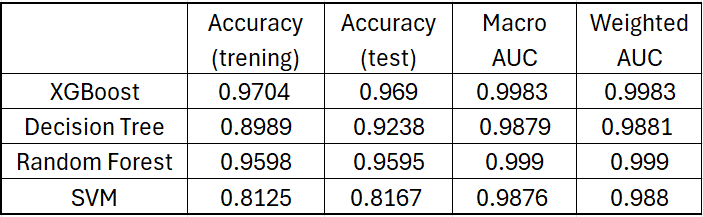

Porównując wszystkie cztery klasyczne modele klasyfikacyjne **model XGBoost osiągnął najlepsze wyniki** we wszystkich kluczowych parametrach. Zarówno dokładność w walidacji krzyżowej (97,04%), jak i dokładność na zbiorze testowym (97%) świadczą o bardzo wysokiej skuteczności tego modelu.

**Model Random Forest znalazł się tuż za XGBoostem**, osiągnął porównywalnie wysokie wyniki (95,98% dokładności testowej, 95,95% dokładności na zbiorze treningowym).

Model drzewa decyzyjnego, mimo prostszej struktury wypadł całkiem dobrze – uzyskał dokładność testową na poziomie 92,38%.

**Najsłabszy wynik osiągnął SVM**, który uzyskał dokładność testową 81,67%. Choć AUC nadal wskazuje na wysoką skuteczność w wykrywaniu klas, niższa dokładność może świadczyć o trudności modelu w prawidłowej klasyfikacji niektórych przypadków, szczególnie tych z klas trudniejszych do odróżnienia.


## **Sieci neuronowe**

### **Sieć neuronowa RSNNS**

Kolejnym modelem jest klasyczna sieć neuronowa MLP zaimplementowana przy użyciu biblioteki RSNNS.

Na początku przygotowano dane, dokonano kodowania cech metodą one-hot oraz przeskalowano je do postaci standardowej, gdzie średnia jest równa 0, a odchylenie standardowe równe 1.  Zmienna docelowa została zakodowana do postaci one-hot za pomocą funkcji decodeClassLabels(). Następnie podzielono dane na zbiór treningowy (80%) i testowy (20%). Po zakończeniu treningu przeprowadzono predykcję klas na danych testowych i ocenę skuteczności przy pomocy macierzy pomyłek.


In [ ]:
library(RSNNS)
library(NeuralNetTools)

X <- dataset %>% select(-NObeyesdad)
Y <- dataset$NObeyesdad

dummy <- dummyVars(~ ., data = X)
X_dummy <- predict(dummy, newdata = X)

Y_onehot <- decodeClassLabels(Y)

min_vals <- apply(X_dummy, 2, min)
max_vals <- apply(X_dummy, 2, max)
X_scaled <- as.data.frame(scale(X_dummy))

train_index <- createDataPartition(Y, p = 0.8, list = FALSE)
X_train <- X_scaled[train_index, ]
Y_train <- Y_onehot[train_index, ]
X_test <- X_scaled[-train_index, ]
Y_test <- Y_onehot[-train_index, ]
Y_test_labels <- Y[-train_index]

model <- mlp(
  X_train, Y_train,
  size = 20,
  learnFuncParams = 0.1,
  maxit = 160,
  shufflePatterns = TRUE,
  inputsTest = X_test,
  targetsTest = Y_test
)

struct <- c(ncol(X_train), 10, ncol(Y_train))
neuralweights(model)

pred_probs <- predict(model, X_test)
pred_class <- factor(apply(pred_probs, 1, which.max), levels = 1:ncol(Y_onehot), labels = colnames(Y_onehot))
caret::confusionMatrix(pred_class, Y_test_labels)

cm <- caret::confusionMatrix(pred_class, Y_test_labels)
cm_table <- as.data.frame(cm$table)
cm_mlp <- cm

$struct
[1] 31 20  7

$wts
$wts$`hidden 1 1`
 [1]           NA  0.309804976  0.246351108 -0.005467481 -5.119317532
 [6] 14.442267418 -0.225888625  0.071201079 -0.209918991 -0.278880537
[11]  0.251178116  0.085408755  0.179533392 -0.146345273 -0.575729907
[16]  0.291117877  0.037644483  0.124511741  0.047238991 -0.334505290
[21]  0.159555569  0.016415959  0.152736232  0.004958006 -0.147856012
[26]  0.589734793  0.104556963 -0.060357116  0.065365292  0.059572570
[31]  0.227150261  0.219445750

$wts$`hidden 1 2`
 [1]          NA -0.94625181 -0.16913444 -0.24759781 -0.97953802  5.47023916
 [7]  0.19652946 -0.99995875  0.85310119 -0.31332439 -1.55861044  1.40319681
[13] -0.19292307  1.53505135 -0.63620883  0.97359151 -0.53091931  0.77481639
[19]  0.12435332  1.75899231 -1.29188740 -0.60231912 -1.00916147 -0.52628374
[25] -0.29678902  0.01662596  0.10449326 -0.11551926  0.89267921 -0.63425821
[31]  0.47911051 -1.00517511

$wts$`hidden 1 3`
 [1]          NA -2.01374435  2.45936155 -2.67593002 -0.07820569 -0.99960798
 [7] -0.22760431  0.34488809 -1.44248414  1.01092100 -0.06181303  0.01780189
[13]  1.08637583 -0.28702292  0.95781600 -0.84558892  0.03115056 -0.29412499
[19]  0.45405024  0.57981461 -0.75896567  3.00692177  0.19593816 -2.27123022
[25]  0.82804346  0.04193973 -0.01146619  0.61752969 -0.38164183  1.09037662
[31] -1.12513685  0.57007486

$wts$`hidden 1 4`
 [1]          NA -2.76918602  2.36757326 -2.28820276  1.24113417 -2.33375931
 [7] -0.07882508  0.11591364  0.88661307 -0.77839613 -0.59913629  0.46558028
[13]  1.69609165  0.80617112  0.11212914  0.17030355  0.89675444 -0.73010808
[19]  0.06853523 -0.01997806  0.15274841 -0.37136275  0.41076714 -0.48083606
[25] -0.85930806  0.63492072  0.30899525 -0.22696729  0.39485717  0.35945204
[31]  0.09052381  0.47447294

$wts$`hidden 1 5`
 [1]           NA -0.092763305  1.729478478 -1.652655005  2.578995466
 [6] -3.831168890 -0.209201783 -0.059547484 -1.055036187  1.281052947
[11]  0.223065183 -0.347674251  0.470878661  1.221864223  0.272545308
[16] -0.247275159 -0.073935792 -0.156011835 -0.135136828  0.017153922
[21] -0.108692177  0.149244025 -0.180925041 -0.494384259  0.111112811
[26]  0.110318333  0.361904413  0.006116837 -0.095805883  0.066368394
[31]  0.487863094 -1.557746887

$wts$`hidden 1 6`
 [1]          NA -1.78058350  0.65324050 -0.92951494 -0.86916727 -2.43173027
 [7] -0.22193083  1.00012267 -0.34869421 -0.44016498 -0.14158408  0.49638703
[13] -0.36110801 -3.34933877  1.91275036 -1.77666080 -0.88081157  0.67900538
[19]  0.26937422  0.20619622 -0.18639794  0.69163179 -1.03818035  0.56340909
[25]  1.19151962 -2.02849102  0.01295844 -1.10880709 -0.58981258 -0.08962372
[31]  0.56774813  1.75949800

$wts$`hidden 1 7`
 [1]          NA -0.75528318 -0.80255073  0.76936656 -1.20335674 -1.14320076
 [7] -0.11773585 -1.10614693 -0.44310197  0.70736176 -0.49954057  0.64684927
[13]  0.74352813  2.67427945 -1.16056299  1.44863701  0.56031746 -1.00459039
[19]  0.60529149  1.20819151 -0.82504189 -1.31568587 -0.08075653 -1.91969633
[25]  2.15473032  0.15902349 -1.21061063 -1.45487726 -0.17906135 -0.10401261
[31]  1.19919121 -0.66098601

$wts$`hidden 1 8`
 [1]           NA  -0.80597538   0.21307592   0.20972665   4.70555162
 [6] -16.74993134   0.25541201  -0.07644302  -0.21079791   0.12849948
[11]  -0.04912023   0.29489246  -0.06207836   0.11496489  -0.75426602
[16]   0.83637810  -0.23456900  -0.16748796   0.03226471   0.25732830
[21]   0.16582531   0.04055353  -0.05392657   0.01363726  -0.31780180
[26]   0.77366030  -0.24304050   0.26130825   0.30509400   0.33907905
[31]  -0.19942008   0.52570969

$wts$`hidden 1 9`
 [1]          NA -1.36683571  0.52073777 -0.71787906 -0.91024250  3.56701899
 [7]  0.24584259  0.05436172 -0.07702927  0.54776454  0.05326079  0.03494908
[13] -0.22019452  0.42656943  0.15419142  0.13863419  0.15236056 -0.63682693
[19]  0.59373975 -0.22175342  0.18296158 -0.67845213  0.57251346 -0.13068470
[25]  0.52767074 -0.16575219 -0.21769913  0.55846930 -0.29301322 -0.4505

Confusion Matrix and Statistics

                     Reference
Prediction            Insufficient_Weight Normal_Weight Obesity_Type_I
  Insufficient_Weight                  51             5              0
  Normal_Weight                         3            47              0
  Obesity_Type_I                        0             0             67
  Obesity_Type_II                       0             0              2
  Obesity_Type_III                      0             0              0
  Overweight_Level_I                    0             5              0
  Overweight_Level_II                   0             0              1
                     Reference
Prediction            Obesity_Type_II Obesity_Type_III Overweight_Level_I
  Insufficient_Weight               0                0                  0
  Normal_Weight                     0                0                  6
  Obesity_Type_I                    0                0                  0
  Obesity_Type_II                  59    

Wizualizacja sieci

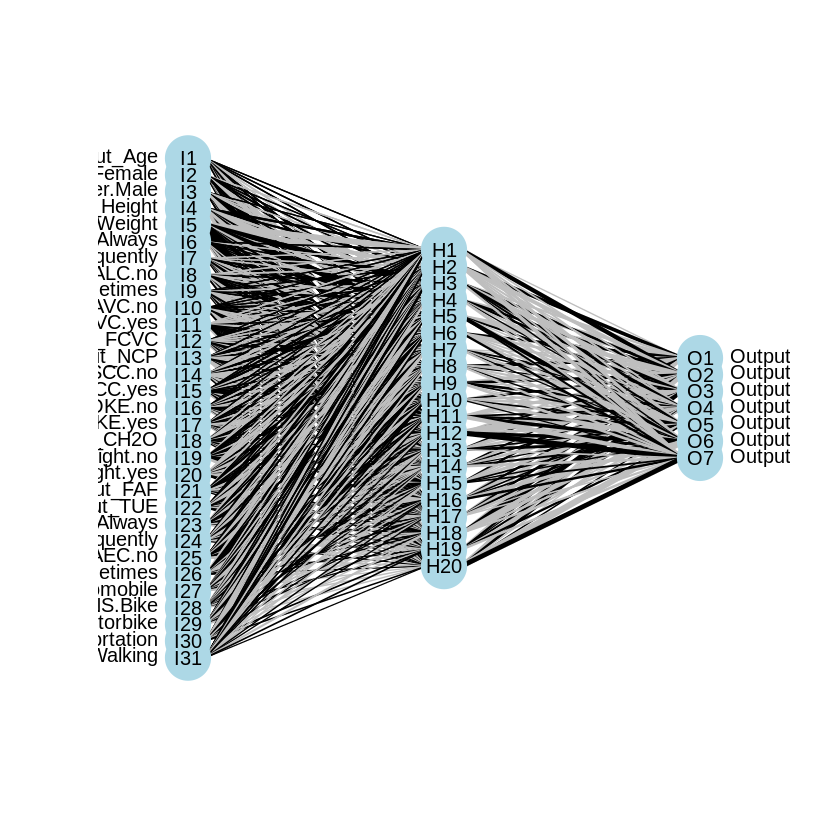

In [ ]:
plotnet(model, struct = struct)

Wykres błędu

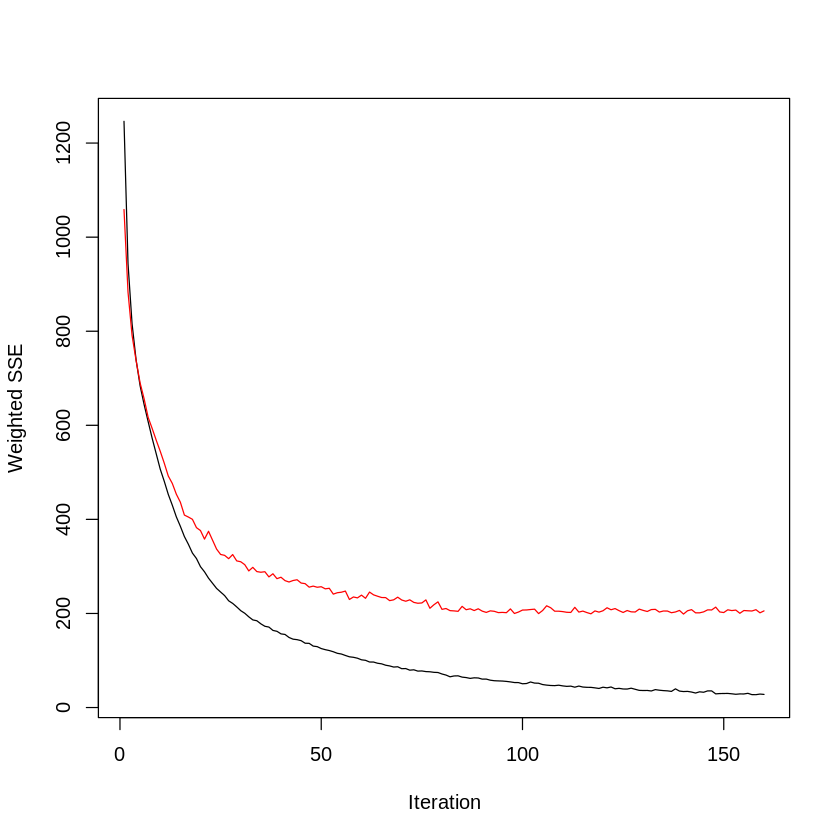

In [ ]:
plotIterativeError(model)

Wizualizacja macierzy pomyłek

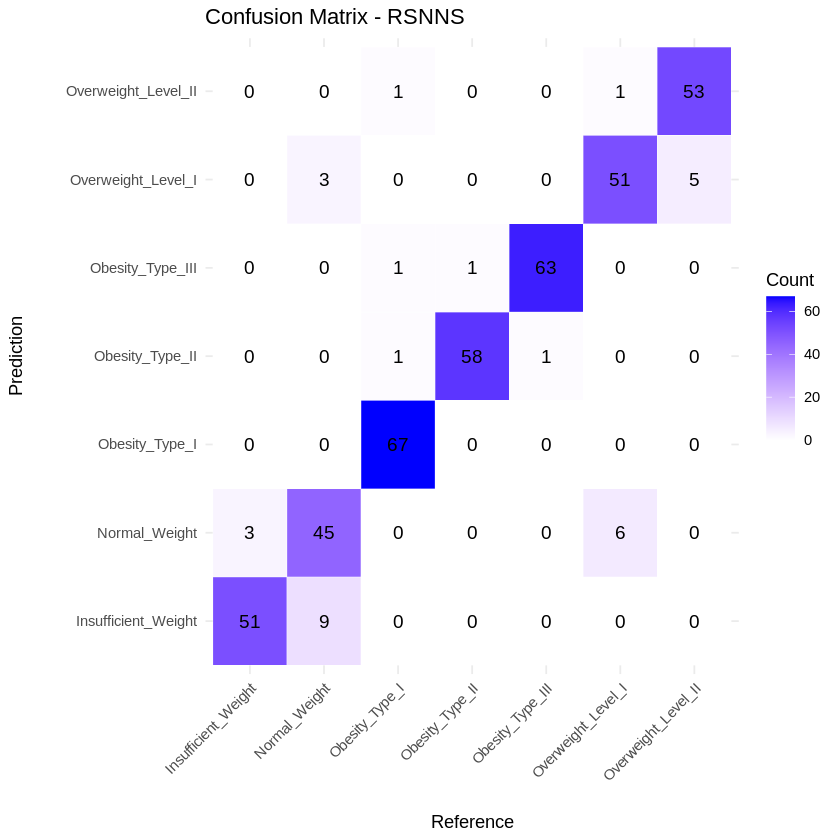

In [ ]:
ggplot(data = cm_table, aes(x = Reference, y = Prediction, fill = Freq)) +
 geom_tile(color = "white") +
 geom_text(aes(label = Freq), color = "black", size = 4) +
 scale_fill_gradient(low = "white", high = "blue") +
 labs(title = "Confusion Matrix - RSNNS", fill = "Count") +
 theme_minimal() +
 theme(axis.text.x = element_text(angle = 45, hjust = 1))

**Najlepsze wyniki zostały osiągnięte przy:** <br> 20 neuronach w warstwie ukrytej, <br>
współczynniku uczenia = 0.1  <br> maksymalnej liczbie epok = 160

Jak pokazuje wykres błędu, sieć uczyła
się stabilnie zmniejszając błąd wraz z kolejnymi epokami. <br> Zwiększenie liczby epok nie poprawiło rezultatu.


Struktura sieci zawierała **31 wejść, 1 warstwę ukrytą z 20 neuronami oraz 7 neuronów wyjściowych** odpowiadających klasom poziomu otyłości.


Model osiągnął bardzo dobre wyniki na zbiorze testowym – **dokładność klasyfikacji wyniosła 94,29%**, a współczynnik **Kappa był równy 0,9333**, co oznacza bardzo wysoką zgodność przewidywań z rzeczywistymi klasami.

Model szczególnie dobrze rozpoznaje klasy Obesity_Type_II i Obesity_Type_III – każda z nich osiągnęła czułość równą 1. Słabiej, ale nadal bardzo dobrze, model radził sobie z rozpoznawaniem klas Obesity_Type_I, Insufficient_Weight i Overweight_Level_II, gdzie zdarzało się kilka pomyłek.

Model wykazał bardzo wysoką czułość i specyficzność dla wszystkich klas.

### **Sieć neuronowa nnet**

Ostatnim modelem wykorzystanym w analizie jest klasyczna sieć neuronowa
zaimplementowana za pomocą funkcji nnet. Najpierw cechy zakodowano metodą onehot encoding i przeskalowano standaryzując je do postaci ze średnią 0 i odchyleniem standardowym 1. Następnie podzielono je na zbiór treningowy i testowy w proporcji 80/20. Po treningu dokonano predykcji na zbiorze testowym, a wyniki zostały przedstawione w postaci macierzy pomyłek. Dodatkowo, z wykorzystaniem pakietu NeuralNetTools, wygenerowano wizualizację struktury sieci.

In [ ]:
library(nnet)
library(NeuralNetTools)

X <- dataset %>% select(-NObeyesdad)
Y <- dataset$NObeyesdad
dummy <- dummyVars(~ ., data = X)
X_dummy <- predict(dummy, newdata = X)
X_scaled <- as.data.frame(scale(X_dummy))
data_nn <- cbind(X_scaled, y = Y)
train_index <- createDataPartition(data_nn$y, p = 0.8, list = FALSE)
train_data <- data_nn[train_index, ]
test_data <- data_nn[-train_index, ]

nnet_model <- nnet(
 y ~ .,
 data = train_data,
 size = 20,
 decay = 0.001,
 maxit = 300,
 trace = FALSE
)

struct <- c(ncol(X_scaled), 20, length(levels(train_data$y)))
neuralweights(nnet_model)

pred_class <- predict(nnet_model, test_data[, -ncol(test_data)], type =
"class")
pred_class <- factor(pred_class, levels = levels(train_data$y))
true_class <- factor(test_data$y, levels = levels(train_data$y))
caret::confusionMatrix(pred_class, true_class)

cm <- caret::confusionMatrix(pred_class, true_class)
cm_table <- as.data.frame(cm$table)
cm_nnet <- cm

$struct
[1] 31 20  7

$wts
$wts$`hidden 1 1`
 [1] -0.226099903  0.277447279 -1.113182954  1.123470489 -3.988420073
 [6]  5.289677429  0.025855321  0.007379681 -0.244749384  0.226455499
[11]  0.194443877 -0.194419858 -0.140285576  2.223249842  0.176744699
[16] -0.167602803 -0.178174422  0.172432876  1.555149774  0.858416914
[21] -0.855996048 -0.543934972  0.679986622 -0.567384952  0.219019590
[26]  0.283914070 -0.053795866 -0.534607014  0.105605972  0.510125385
[31]  0.308182305  0.250297297

$wts$`hidden 1 2`
 [1]  4.519440318 -0.118300181 -0.046404398  0.039920725 -3.299382313
 [6]  9.765799557 -0.101456310 -0.026383222 -0.178484818  0.194105943
[11]  0.051033479 -0.047615843 -0.508389480 -0.112514096 -0.083813645
[16]  0.097987201  0.065813692 -0.065591272 -0.017502411  0.095244072
[21] -0.101935279 -0.260799577 -0.170716845 -0.040317382  0.080556737
[26] -0.187863281  0.027713023  0.057526040 -0.200347977 -0.028928095
[31] -0.027558196 -0.007970343

$wts$`hidden 1 3`
 [1]  2.27046701  0.80121849  0.15056089 -0.14624579 -1.81597771  3.26406550
 [7] -0.03472792  1.54575508  0.67091538 -1.24691491 -1.86125044  1.85371494
[13] -0.63165718 -1.16659533  1.65644178 -1.65050958 -0.45471315  0.45156888
[19] -0.54995218 -0.28548550  0.28483187 -0.15721187 -1.76851657  0.40506620
[25] -1.93235061 -0.52328744  1.70946932 -0.83566380 -0.10863502 -0.14288819
[31]  0.40864914  1.13733542

$wts$`hidden 1 4`
 [1]  1.63056689  0.86936759  0.84414006 -0.84396266  1.56192394 -2.60374617
 [7] -0.02387404  1.44924094  1.85864234 -2.34993527  0.38651917 -0.38648364
[13]  0.32242259  0.56008784  1.38780721 -1.37752027  0.51319344 -0.50282046
[19] -0.43232763 -1.66101340  1.66247580  1.23783744 -0.88455090 -1.37726730
[25]  1.02739475  0.09534252 -0.33050269  0.72718167 -0.18488119 -0.04024852
[31] -0.69420927  0.08371015

$wts$`hidden 1 5`
 [1] -5.5194337916  0.3515837443 -0.1097835707  0.1046466476  0.8193105860
 [6] -6.0845888320 -0.0130118067  0.2363521865 -0.0459389829 -0.0549885206
[11]  0.1623184840 -0.1620758993 -0.3479546569  0.3059360679  0.1396140832
[16] -0.1411990564 -0.0076568291  0.0116658937  0.3037545412 -0.1169800478
[21]  0.1263050957 -0.5732014606 -0.5468800679 -0.1132938410 -0.0006005091
[26]  0.0478987734  0.0303912066  0.1387826810  0.1384405453  0.0842844666
[31] -0.2142593105  0.1239726163

$wts$`hidden 1 6`
 [1] -3.17407112 -1.57456939 -0.60859009  0.59782612  1.69061768 -3.57610619
 [7] -0.68566536  0.47570218  1.54090537 -1.63861424 -0.05081073  0.05849809
[13]  1.31198505 -0.19317954 -0.23029917  0.23087282 -0.32074991  0.31510265
[19]  0.23718832  0.94929900 -0.94908317  1.62077510  0.16445539  0.09822986
[25]  0.03370433 -0.36192098  0.09363315 -1.26742621  0.06581077  0.42507741
[31]  1.02724665  0.25690404

$wts$`hidden 1 7`
 [1]  0.54652688  1.98334040 -1.72439614  1.73090206  0.63567969  4.59504109
 [7]  0.02877048 -0.05066306 -1.30358642  1.28909374  0.54243184 -0.54352594
[13] -0.62217840 -0.52407486  0.78157156 -0.77557552  1.87445477 -1.86735791
[19] -0.21660107 -1.12106993  1.13344599 -0.30285502 -1.58396214 -0.12438295
[25] -1.34137891  0.91623900  0.84071713  0.71264665  0.50068299 -0.37430404
[31] -0.71707949  0.09967227

$wts$`hidden 1 8`
 [1]  0.60901628  2.74674542  2.72395603 -2.71582662 -0.90458604  2.80816844
 [7] -0.02402764  0.09014121 -0.90384367  0.84602394  0.37517983 -0.36673661
[13] -0.14308854 -0.71298947 -0.38471908  0.38026370  0.33230396 -0.32707563
[19]  1.72187277  0.24793747 -0.24915975 -0.53585895  3.08591563 -0.35682377
[25] -0.34576362  1.11271523 -0.02143304 -1.67695804 -0.01779899  0.17935213
[31]  1.54548326  0.06867489

$wts$`hidden 1 9`
 [1] -1.41121410 -0.57914800 -0.26691398  0.27065736 -0.92291386  3.72444093
 [7]  0.02184636 -0.16141942 -0.40965715  0.46783725  1.39250406 -1.39938193
[13]  0.62819672  0.64681877 -0.05671753  0.06265946 -0.96093135  0.96228818
[19] -0.48331804  1.10787142 -1.10621117  0.76329896 -1.27524324  1.11201726
[25]  0.76964619 -0.38058906 -0.97998488

Confusion Matrix and Statistics

                     Reference
Prediction            Insufficient_Weight Normal_Weight Obesity_Type_I
  Insufficient_Weight                  53             4              0
  Normal_Weight                         1            53              0
  Obesity_Type_I                        0             0             66
  Obesity_Type_II                       0             0              0
  Obesity_Type_III                      0             0              1
  Overweight_Level_I                    0             0              0
  Overweight_Level_II                   0             0              3
                     Reference
Prediction            Obesity_Type_II Obesity_Type_III Overweight_Level_I
  Insufficient_Weight               0                0                  0
  Normal_Weight                     0                0                  6
  Obesity_Type_I                    0                0                  1
  Obesity_Type_II                  59    

Wizualizacja sieci

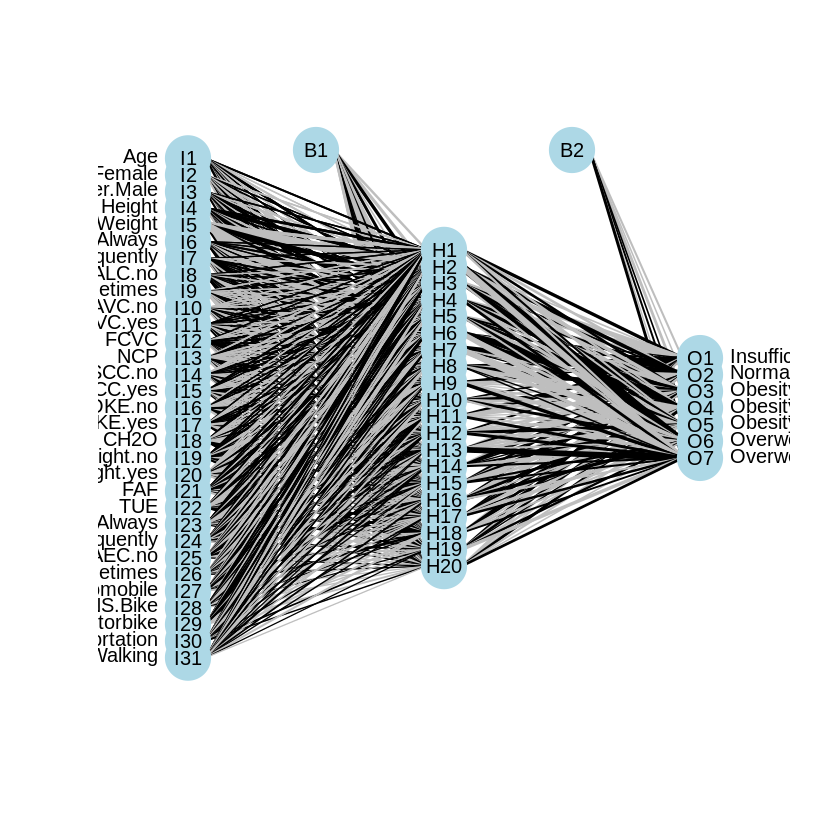

In [ ]:
plotnet(nnet_model, struct = struct)

Wizualizacja macierzy pomyłek

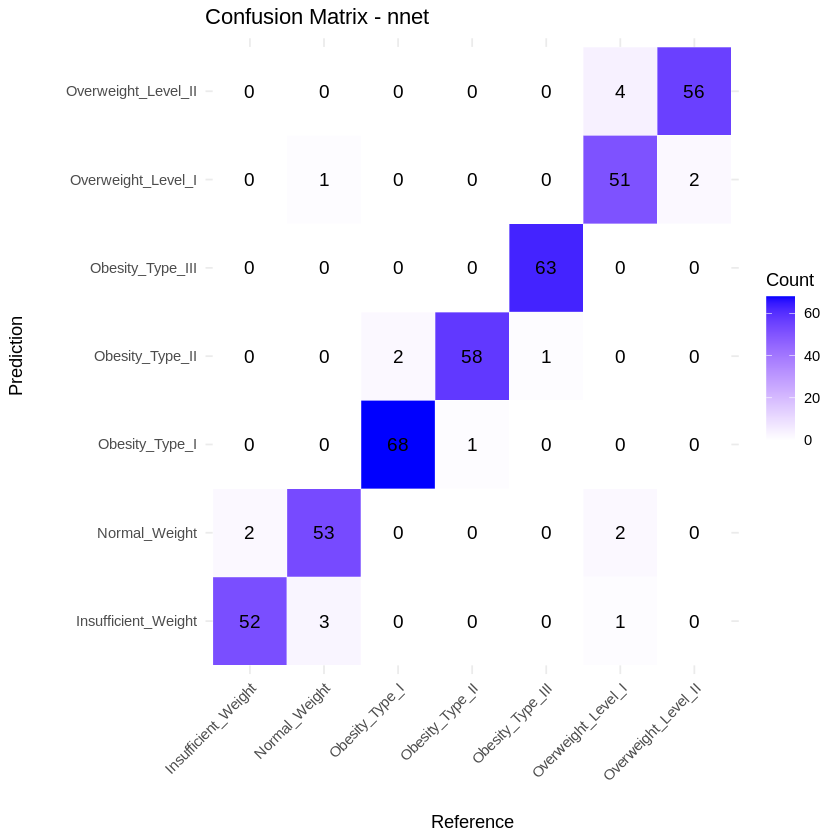

In [ ]:
ggplot(data = cm_table, aes(x = Reference, y = Prediction, fill = Freq)) +
 geom_tile(color = "white") +
 geom_text(aes(label = Freq), color = "black", size = 4) +
 scale_fill_gradient(low = "white", high = "blue") +
 labs(title = "Confusion Matrix - nnet", fill = "Count") +
 theme_minimal() +
 theme(axis.text.x = element_text(angle = 45, hjust = 1))

Tutaj również przetestowano różne kombinacje liczby neuronów w warstwie ukrytej,
wartości parametru decay oraz liczby iteracji uczenia. **Najlepsze rezultaty osiągnięto przy 20 neuronach, decay = 0.001 i 300 epokach.**

Model uzyskał **dokładność klasyfikacji 95%**, a współczynnik **Kappa** wyniósł
**0,9416**, co świadczy o prawie idealnym dopasowaniu modelu do danych testowych.


Szczególnie dobrze sklasyfikowane zostały klasy Obesity_Type_II oraz
Obesity_Type_III, dla których czułość i precyzja sięgają 100%.

Trochę więcej
pomyłek wystąpiło np. między klasami Overweight_Level_I i Overweight_Level_II, co jest normalne z uwagi na ich podobieństwo, ale również dla nich dokładność jest bardzo wysoka.

## **Porównanie skuteczności sieci neuronowych**

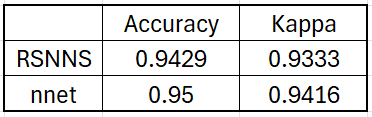

**Obie sieci neuronowe osiągnęły bardzo wysoką skuteczność klasyfikacji** – **dokładność** przekroczyła **94%**. Model RSNNS uzyskał accuracy 94,3% i charakteryzował się stabilnym przebiegiem uczenia przy mniejszej liczbie epok. Model nnet, mimo dłuższego treningu (300 iteracji), osiągnął nieco wyższą dokładność – 95% oraz wyższy współczynnik Kappa (0,9416). W obu przypadkach największe trudności sprawiało rozróżnienie klas sąsiadujących (Overweight_Level_I i II), natomiast klasy otyłości były rozpoznawane praktycznie bezbłędnie. O**ba modele są bardzo skuteczne, z niewielką przewagą modelu nnet** pod względem dokładności testowej.